# Hull - Leak Safe Baseline

- The training data also contain the public test set. It is the last 180 days, see [data description](https://www.kaggle.com/competitions/hull-tactical-market-prediction/data). Let's remove this part overall to get a meaningful score on the current public leaderboard.
- We are supposed to predict the strategy by day, which is something that depends on the forward_return and risk_free_rate (and some overall effect). This makes me wonder if we need to estimate both of them at the same time, and then deriving a certain stratgey. However, in [this discussion answer](https://www.kaggle.com/competitions/hull-tactical-market-prediction/discussion/608349#3299060), this optimization is done analytically (withouth considering penalty effects). Thus let's take these targets as the true targets to be predicted.
- Otherwise we are modelling as simple as in the [Hull Starter Notebook](https://www.kaggle.com/code/laurentlanteigne/hull-starter-notebook): No time effect, same features and same model.
- Note, the training dataset will be updated throughout the competition.

**All comments welcome!**

## Import & Settings

In [1]:
#!pip install neuralforecast pytorch-lightning

In [2]:
import os
import pathlib
import numpy as np
import pandas as pd
import polars as pl 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
import plotly as py
init_notebook_mode(connected=True) 
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler
import kaggle_evaluation.default_inference_server
from metric import score as hull_score
import re
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from IPython.display import display
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import lightgbm as lgb

**EDAProtocol:UncoveringTemporalPatterns,tationarity,andFeatureRelationships**


==== forward_returns description ====
count    9048.000000
mean        0.000470
std         0.010535
min        -0.039754
1%         -0.031565
5%         -0.017678
25%        -0.004321
50%         0.000661
75%         0.005891
95%         0.016763
99%         0.031500
max         0.040661
Name: forward_returns, dtype: float64
skewness: -0.17817828108607422
kurtosis: 2.198818863130394

==== market_forward_excess_returns description ====
count    9048.000000
mean        0.000052
std         0.010552
min        -0.040582
1%         -0.031946
5%         -0.018077
25%        -0.004751
50%         0.000257
75%         0.005469
95%         0.016356
99%         0.031089
max         0.040551
Name: market_forward_excess_returns, dtype: float64
skewness: -0.18002441611782993
kurtosis: 2.2444742582210617


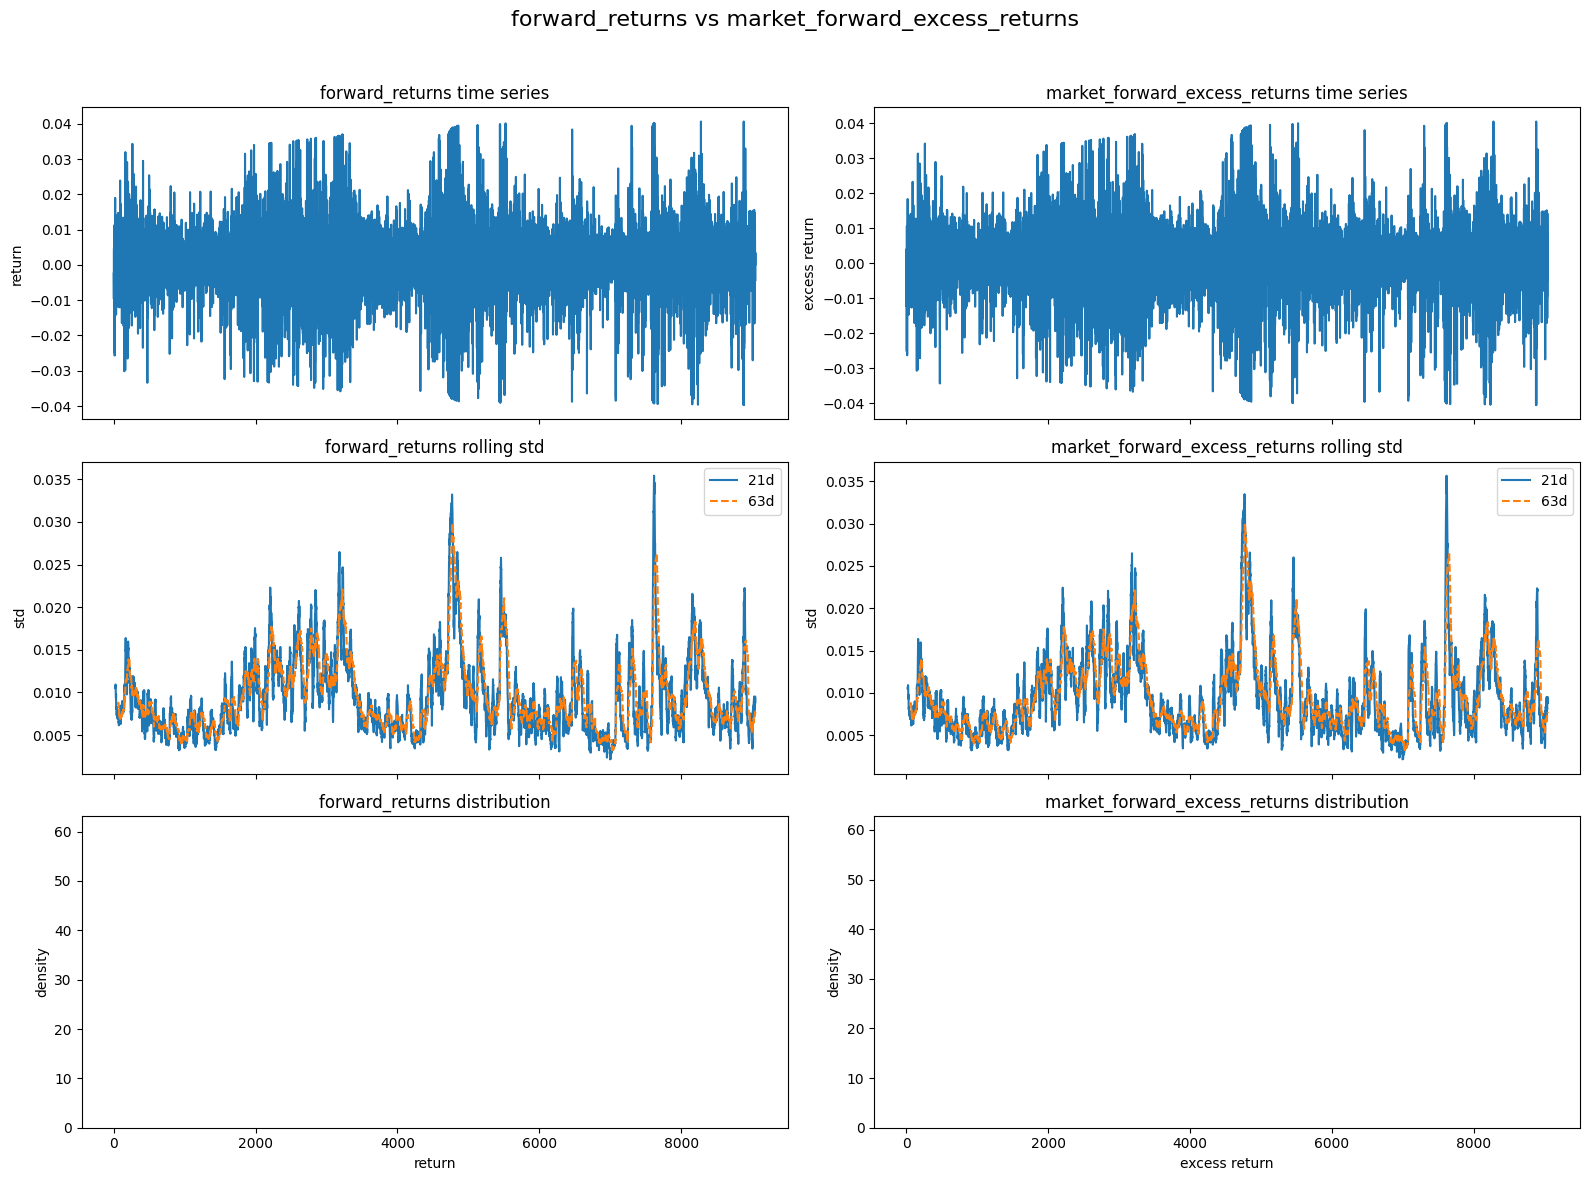

In [3]:
BASE_DIR = pathlib.Path("/kaggle/input/hull-tactical-market-prediction")
train_path = BASE_DIR / "train.csv"

df = pd.read_csv(train_path)
df = df.sort_values("date_id").reset_index(drop=True)

cols = ["forward_returns", "risk_free_rate", "market_forward_excess_returns"]
ts = df[["date_id"] + cols].dropna()

# ========= 2. 简单统计分布信息 =========
for c in ["forward_returns", "market_forward_excess_returns"]:
    print(f"\n==== {c} description ====")
    print(ts[c].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
    print("skewness:", ts[c].skew())
    print("kurtosis:", ts[c].kurt())

# ========= 3. 计算 rolling std =========
# 常见：21 天（约 1 个月），63 天（约 3 个月）
windows = [21, 63]
for c in ["forward_returns", "market_forward_excess_returns"]:
    for w in windows:
        ts[f"{c}_roll_std_{w}"] = ts[c].rolling(w).std()

# ========= 4. 画图：时间轨迹 + rolling std + 分布 =========
plt.style.use("default")
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex='col')
fig.suptitle("forward_returns vs market_forward_excess_returns", fontsize=16)

x = ts["date_id"]

# --- 第一行：时间序列轨迹 ---
axes[0, 0].plot(x, ts["forward_returns"])
axes[0, 0].set_title("forward_returns time series")
axes[0, 0].set_ylabel("return")

axes[0, 1].plot(x, ts["market_forward_excess_returns"])
axes[0, 1].set_title("market_forward_excess_returns time series")
axes[0, 1].set_ylabel("excess return")

# --- 第二行：rolling std ---
for w, ls in zip(windows, ["-", "--"]):
    axes[1, 0].plot(x, ts[f"forward_returns_roll_std_{w}"], linestyle=ls, label=f"{w}d")
axes[1, 0].set_title("forward_returns rolling std")
axes[1, 0].set_ylabel("std")
axes[1, 0].legend()

for w, ls in zip(windows, ["-", "--"]):
    axes[1, 1].plot(x, ts[f"market_forward_excess_returns_roll_std_{w}"],
                    linestyle=ls, label=f"{w}d")
axes[1, 1].set_title("market_forward_excess_returns rolling std")
axes[1, 1].set_ylabel("std")
axes[1, 1].legend()

# --- 第三行：分布直方图 ---
axes[2, 0].hist(ts["forward_returns"], bins=50, density=True)
axes[2, 0].set_title("forward_returns distribution")
axes[2, 0].set_xlabel("return")
axes[2, 0].set_ylabel("density")

axes[2, 1].hist(ts["market_forward_excess_returns"], bins=50, density=True)
axes[2, 1].set_title("market_forward_excess_returns distribution")
axes[2, 1].set_xlabel("excess return")
axes[2, 1].set_ylabel("density")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [4]:
BASE_DIR = pathlib.Path("/kaggle/input/hull-tactical-market-prediction")
train_path = BASE_DIR / "train.csv"

df = pd.read_csv(train_path)

df = df.sort_values("date_id").reset_index(drop=True)

TARGET_COL = "market_forward_excess_returns"
INFO_COLS = ["date_id", "forward_returns", "risk_free_rate"]


all_feature_cols = [
    c for c in df.columns
    if c not in INFO_COLS + [TARGET_COL]
]

print("num of features:", len(all_feature_cols))

all_feature_cols[:]


num of features: 94


['D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'E1',
 'E10',
 'E11',
 'E12',
 'E13',
 'E14',
 'E15',
 'E16',
 'E17',
 'E18',
 'E19',
 'E2',
 'E20',
 'E3',
 'E4',
 'E5',
 'E6',
 'E7',
 'E8',
 'E9',
 'I1',
 'I2',
 'I3',
 'I4',
 'I5',
 'I6',
 'I7',
 'I8',
 'I9',
 'M1',
 'M10',
 'M11',
 'M12',
 'M13',
 'M14',
 'M15',
 'M16',
 'M17',
 'M18',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'P1',
 'P10',
 'P11',
 'P12',
 'P13',
 'P2',
 'P3',
 'P4',
 'P5',
 'P6',
 'P7',
 'P8',
 'P9',
 'S1',
 'S10',
 'S11',
 'S12',
 'S2',
 'S3',
 'S4',
 'S5',
 'S6',
 'S7',
 'S8',
 'S9',
 'V1',
 'V10',
 'V11',
 'V12',
 'V13',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9']

In [5]:

groups = {}

for col in all_feature_cols:
    m = re.match(r"([A-Z]+)\d*", col)  # 匹配开头的大写字母
    if m:
        prefix = m.group(1)           # 比如 'V', 'M', 'E'
    else:
        prefix = "OTHER"
    groups.setdefault(prefix, []).append(col)

# 看看每一组有哪些变量
for g, cols in groups.items():
    print(f"Group {g}: {len(cols)} features")
    print("  ", cols[:10], "..." if len(cols) > 10 else "")


Group D: 9 features
   ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9'] 
Group E: 20 features
   ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18'] ...
Group I: 9 features
   ['I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9'] 
Group M: 18 features
   ['M1', 'M10', 'M11', 'M12', 'M13', 'M14', 'M15', 'M16', 'M17', 'M18'] ...
Group P: 13 features
   ['P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5', 'P6'] ...
Group S: 12 features
   ['S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7'] ...
Group V: 13 features
   ['V1', 'V10', 'V11', 'V12', 'V13', 'V2', 'V3', 'V4', 'V5', 'V6'] ...


In [6]:
def expanding_zscore_group(df,feature_cols,min_periods = 30):
    """
    对 feature_cols 列进行 expanding 标准化：
    对时刻 t，只使用 1..(t-1) 的均值和 std（shift(1) 避免泄露）
    返回：包含 z-score 的 DataFrame（列名自动加 _z）
    """
    X = df[feature_cols]
    #expanding mean and std, based on time series
    exp_mean = X.expanding(min_periods = min_periods).mean().shift(1)
    exp_std = X.expanding(min_periods = min_periods).std(ddof=0).shift(1)

    z = (X - exp_mean)/exp_std

    #rename col
    z.columns = [c + "_z" for c in feature_cols]
    return z



In [7]:
#for each group iterate expanding standard
df = df.sort_values("date_id").reset_index(drop=True)

all_z_cols = []   # 存所有 _z 列名，后面一起加入 df

for gname, cols in groups.items():
    print(f"Processing group {gname} with {len(cols)} features...")

    z_df = expanding_zscore_group(df, cols, min_periods=30)

    
    for col in z_df.columns:
        df[col] = z_df[col]
        all_z_cols.append(col)
print("nums of standard features =", len(all_z_cols))

Processing group D with 9 features...
Processing group E with 20 features...
Processing group I with 9 features...
Processing group M with 18 features...
Processing group P with 13 features...
Processing group S with 12 features...
Processing group V with 13 features...
nums of standard features = 94


In [8]:
#drou off the min_peridos row
df_clean = df.dropna(subset=all_z_cols).reset_index(drop=True)

print("Orign sample", len(df))
print("After clean sample：", len(df_clean))


Orign sample 9048
After clean sample： 2049



===== Group D: 9 num of feature =====


,D1,D2,D3,D4,D5,D6,D7,D8,D9
D1,1.000000,1.000000,-0.004992,0.005718,0.013574,0.009073,-0.033515,0.011063,-0.003544
D2,1.000000,1.000000,-0.004992,0.005718,0.013574,0.009073,-0.033515,0.011063,-0.003544
D3,-0.004992,-0.004992,1.000000,0.006191,-0.104895,0.107121,-0.049092,-0.088584,-0.090189
D4,0.005718,0.005718,0.006191,1.000000,0.007450,-0.008033,-0.000171,0.005866,0.006674
D5,0.013574,0.013574,-0.104895,0.007450,1.000000,0.271472,0.079460,0.494592,0.495261
D6,0.009073,0.009073,0.107121,-0.008033,0.271472,1.000000,0.119954,0.228312,0.228620
D7,-0.033515,-0.033515,-0.049092,-0.000171,0.079460,0.119954,1.000000,-0.047096,0.209418
D8,0.011063,0.011063,-0.088584,0.005866,0.494592,0.228312,-0.047096,1.000000,-0.166957
D9,-0.003544,-0.003544,-0.090189,0.006674,0.495261,0.228620,0.209418,-0.166957,1.000000


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



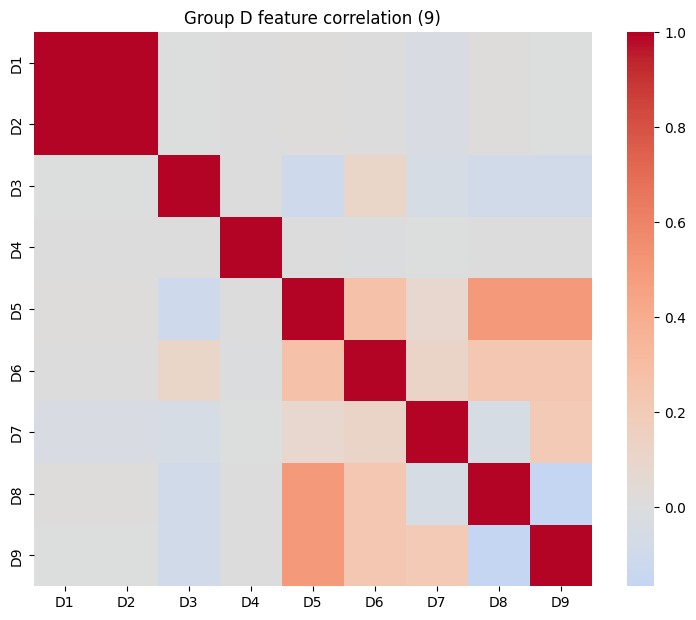


===== Group E: 20 num of feature =====


,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9
E1,1.000000,-0.389589,0.303883,0.239939,0.318757,-0.000180,0.293860,-0.448536,-0.508725,-0.429652,-0.058725,-0.166593,-0.164479,-0.020919,-0.070877,-0.205940,-0.066426,-0.247394,0.155511,0.261615
E10,-0.389589,1.000000,-0.156915,-0.099919,-0.049915,-0.035011,-0.016725,0.078935,0.135439,0.141014,0.135095,-0.251196,0.466832,-0.195067,-0.186766,0.331920,-0.089538,0.134500,-0.181595,-0.156992
E11,0.303883,-0.156915,1.000000,0.454214,0.550353,0.101713,0.143207,0.089658,0.054507,0.074782,-0.117378,0.181193,-0.139111,0.260289,0.000066,-0.204541,0.157027,0.019919,0.000113,0.203371
E12,0.239939,-0.099919,0.454214,1.000000,0.206893,0.473540,0.189656,0.131547,0.099679,0.091103,-0.126531,0.159726,-0.257423,0.255019,-0.013256,-0.172809,0.093034,0.048578,0.026368,0.250895
E13,0.318757,-0.049915,0.550353,0.206893,1.000000,0.212014,0.065645,-0.123871,-0.112063,-0.070829,-0.081773,-0.051072,-0.008002,-0.033489,-0.106378,0.026531,0.095001,-0.149473,0.003121,0.018564
E14,-0.000180,-0.035011,0.101713,0.473540,0.212014,1.000000,-0.004088,0.074567,0.099534,0.093786,-0.011719,0.120613,-0.141973,0.125482,-0.052683,-0.079740,0.151868,0.016056,0.042387,0.035589
E15,0.293860,-0.016725,0.143207,0.189656,0.065645,-0.004088,1.000000,-0.208189,-0.369082,-0.246473,-0.209638,-0.322513,-0.199290,0.084419,-0.226614,0.003681,-0.227651,0.047249,-0.011472,0.853987
E16,-0.448536,0.078935,0.089658,0.131547,-0.123871,0.074567,-0.208189,1.000000,0.928154,0.800463,-0.073165,0.682996,-0.047710,0.583573,0.185965,-0.115021,0.142774,0.610997,-0.257605,0.003499
E17,-0.508725,0.135439,0.054507,0.099679,-0.112063,0.099534,-0.369082,0.928154,1.000000,0.886213,0.005112,0.708912,0.107449,0.534533,0.097768,-0.148002,0.244388,0.466097,-0.202439,-0.155385
E18,-0.429652,0.141014,0.074782,0.091103,-0.070829,0.093786,-0.246473,0.800463,0.886213,1.000000,-0.011381,0.742979,0.075672,0.633991,0.055059,-0.285537,0.350756,0.374850,-0.200421,-0.033011


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



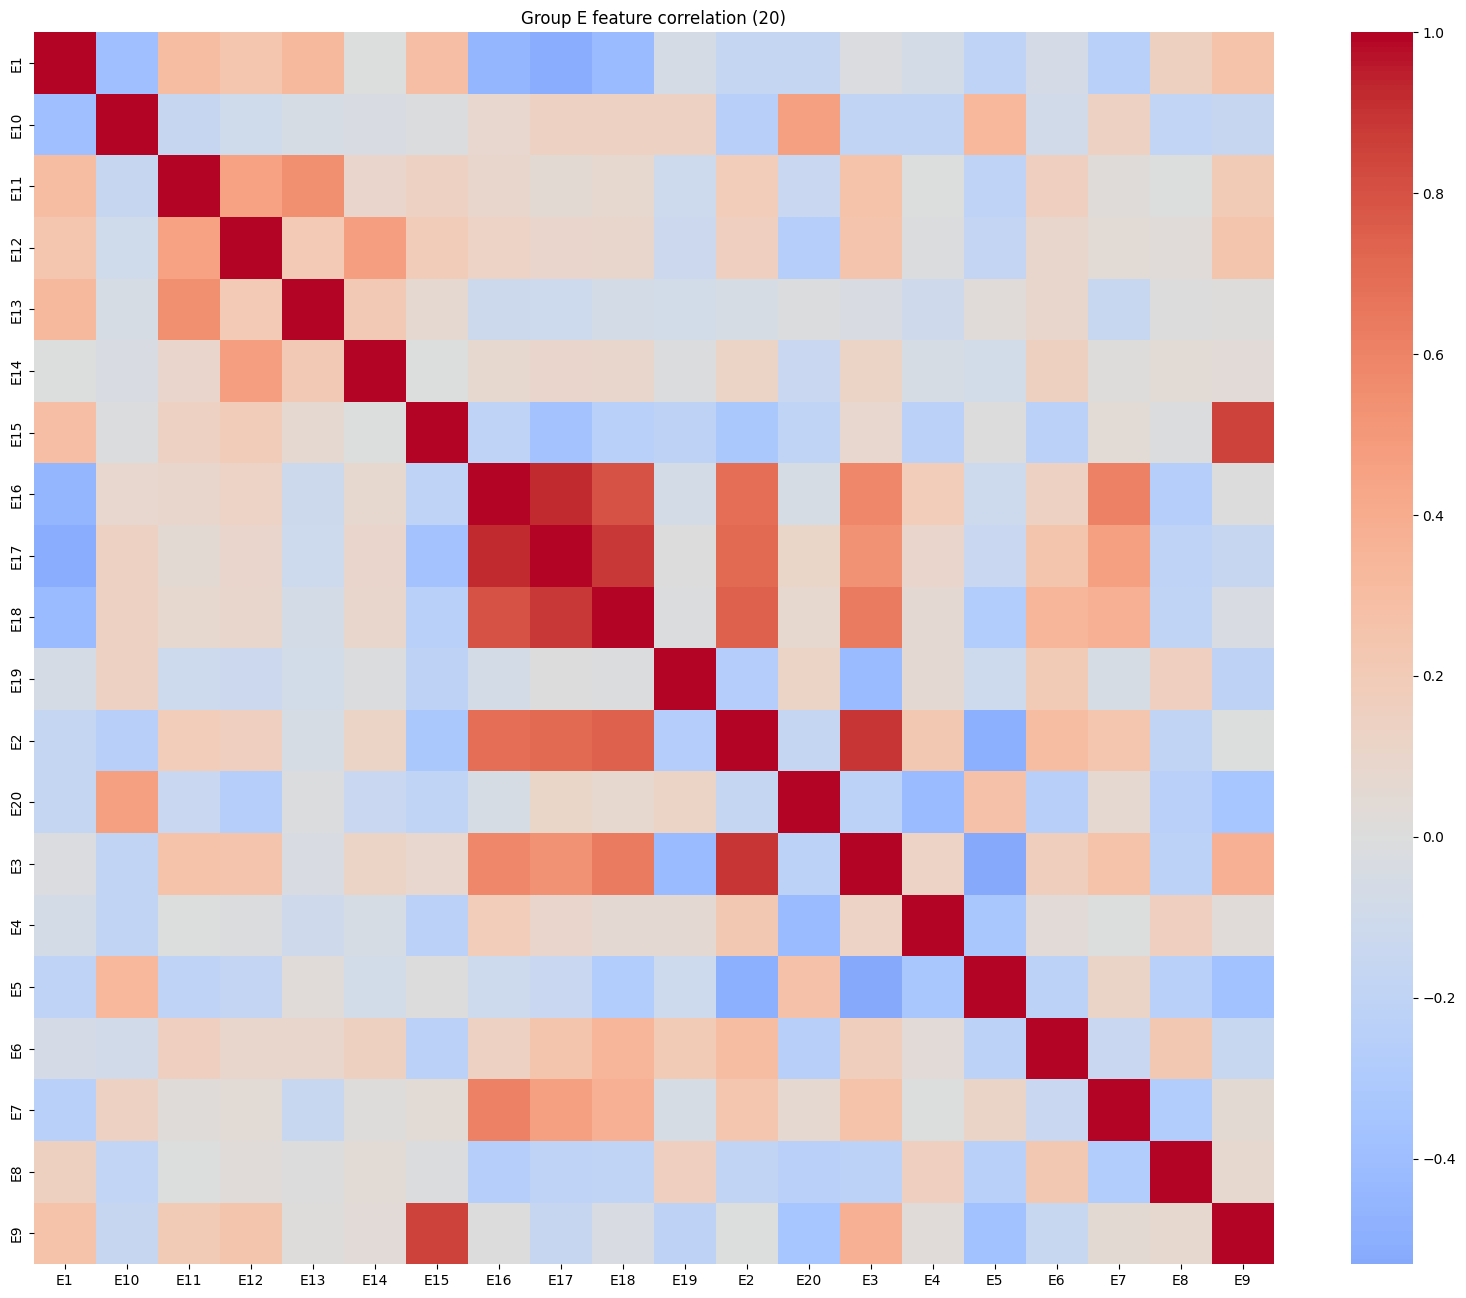


===== Group I: 9 num of feature =====


,I1,I2,I3,I4,I5,I6,I7,I8,I9
I1,1.000000,-0.162168,0.115197,0.211780,0.036348,-0.465246,0.725892,0.416830,0.035589
I2,-0.162168,1.000000,-0.349045,-0.195229,0.191136,0.172124,-0.387835,-0.203221,0.192235
I3,0.115197,-0.349045,1.000000,0.075957,-0.076824,0.128512,0.363218,0.145944,-0.075495
I4,0.211780,-0.195229,0.075957,1.000000,-0.093944,-0.475427,0.504771,0.829794,-0.093644
I5,0.036348,0.191136,-0.076824,-0.093944,1.000000,-0.087818,-0.062511,-0.115660,0.999689
I6,-0.465246,0.172124,0.128512,-0.475427,-0.087818,1.000000,-0.597310,-0.571035,-0.086414
I7,0.725892,-0.387835,0.363218,0.504771,-0.062511,-0.597310,1.000000,0.758034,-0.062878
I8,0.416830,-0.203221,0.145944,0.829794,-0.115660,-0.571035,0.758034,1.000000,-0.115903
I9,0.035589,0.192235,-0.075495,-0.093644,0.999689,-0.086414,-0.062878,-0.115903,1.000000


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



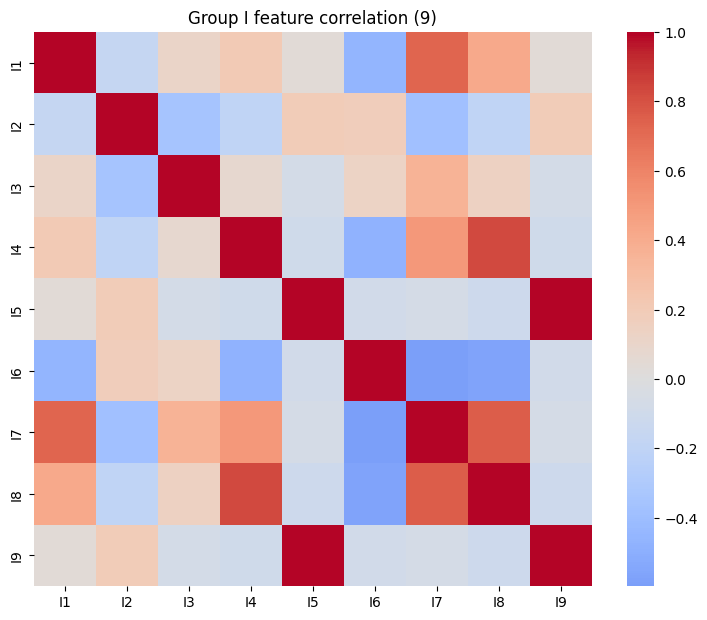


===== Group M: 18 num of feature =====


,M1,M10,M11,M12,M13,M14,M15,M16,M17,M18,M2,M3,M4,M5,M6,M7,M8,M9
M1,1.000000,-0.492572,0.425149,0.187446,0.641179,-0.116376,0.006204,-0.088026,0.137709,0.087120,0.222354,0.394735,-0.173536,0.203583,0.021022,0.143167,-0.084869,-0.219198
M10,-0.492572,1.000000,-0.252812,-0.435667,-0.593412,0.179682,-0.038830,0.032629,-0.007643,-0.136887,-0.115420,-0.417900,-0.020057,-0.225134,-0.241072,-0.188604,-0.073575,-0.010742
M11,0.425149,-0.252812,1.000000,0.180757,-0.005845,-0.490022,0.022210,-0.278989,-0.164890,-0.133380,-0.004522,0.285223,-0.062206,0.120637,-0.479433,-0.344762,0.031883,-0.792796
M12,0.187446,-0.435667,0.180757,1.000000,0.318327,-0.385877,0.077456,-0.238206,0.258350,-0.266006,0.114962,0.000040,-0.009488,0.111169,0.010856,0.418133,0.227896,-0.302718
M13,0.641179,-0.593412,-0.005845,0.318327,1.000000,0.134241,-0.042713,0.272196,-0.147287,0.438685,0.157449,0.255787,-0.029014,0.216641,0.349404,0.362296,0.022679,0.237810
M14,-0.116376,0.179682,-0.490022,-0.385877,0.134241,1.000000,-0.057799,0.678372,-0.181664,0.212694,0.031446,0.023902,-0.032179,0.066998,0.366439,0.304216,0.076084,0.429545
M15,0.006204,-0.038830,0.022210,0.077456,-0.042713,-0.057799,1.000000,-0.112047,0.147249,-0.173076,0.010773,0.000647,-0.031115,-0.008459,0.010662,0.035890,0.063081,-0.088534
M16,-0.088026,0.032629,-0.278989,-0.238206,0.272196,0.678372,-0.112047,1.000000,-0.377402,0.556614,0.090124,0.118870,-0.044688,0.214592,0.299717,0.168657,0.110766,0.409900
M17,0.137709,-0.007643,-0.164890,0.258350,-0.147287,-0.181664,0.147249,-0.377402,1.000000,-0.557081,-0.014492,0.169224,0.037394,-0.015658,0.138322,0.339235,-0.046535,0.007197
M18,0.087120,-0.136887,-0.133380,-0.266006,0.438685,0.212694,-0.173076,0.556614,-0.557081,1.000000,0.117806,0.150102,-0.022558,0.286401,0.220738,-0.130682,-0.184347,0.471439


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



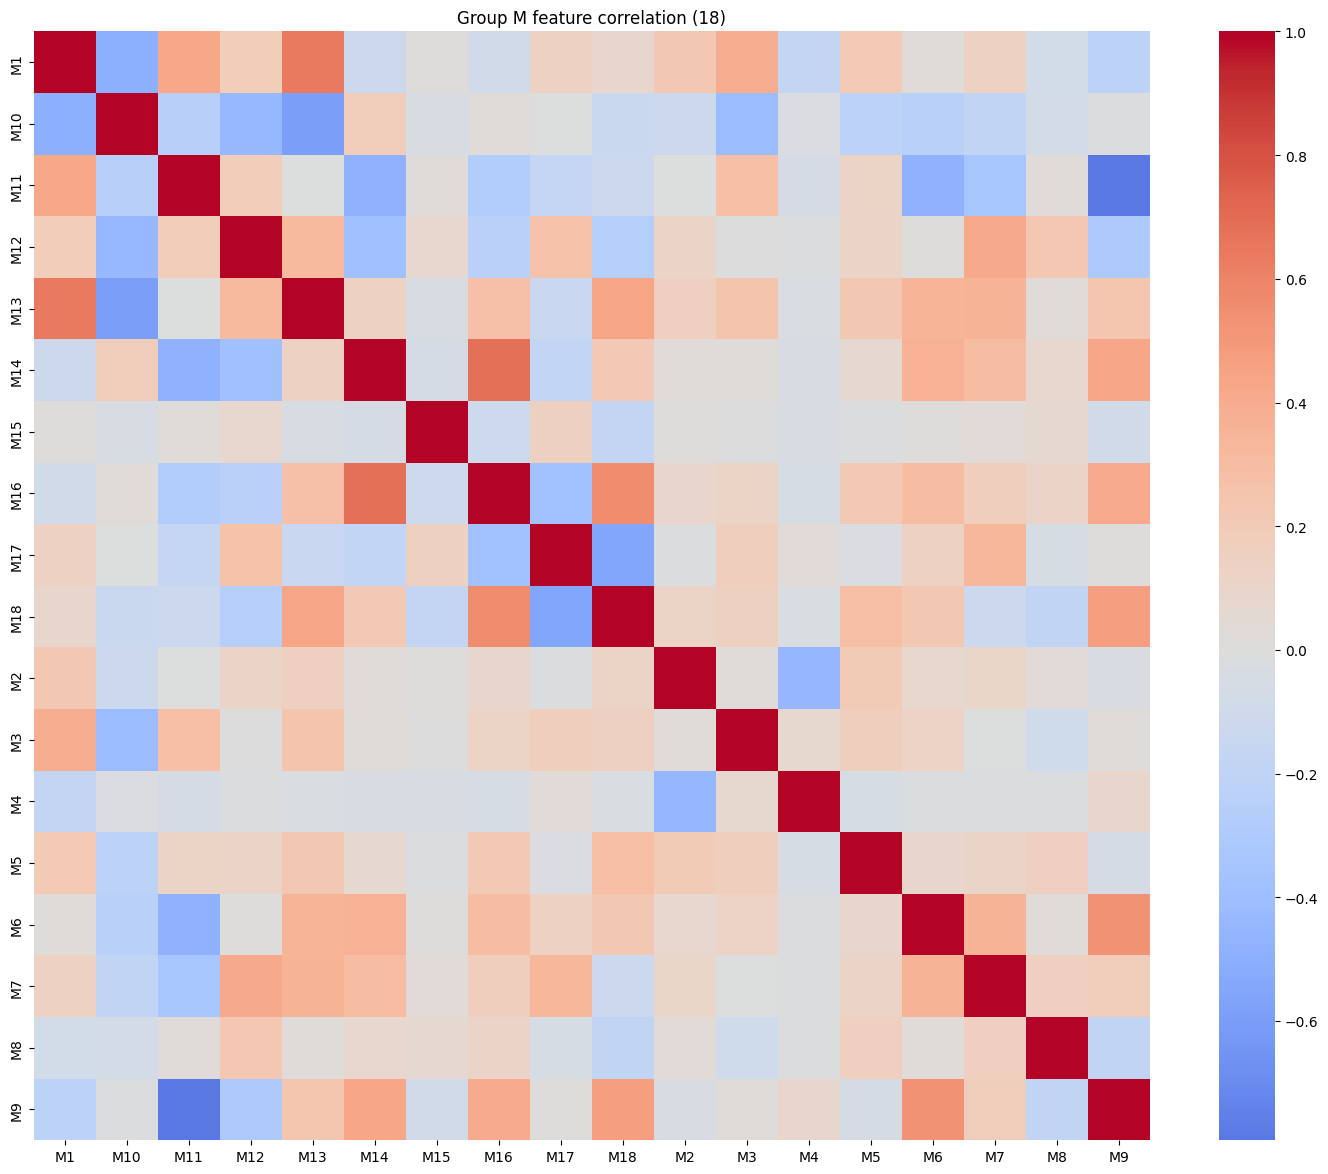


===== Group P: 13 num of feature =====


,P1,P10,P11,P12,P13,P2,P3,P4,P5,P6,P7,P8,P9
P1,1.000000,-0.347397,-0.244919,-0.167763,0.464974,-0.052291,-0.008525,-0.045563,0.083629,-0.089585,0.037663,-0.174327,0.022532
P10,-0.347397,1.000000,0.938108,0.232604,-0.215404,-0.623735,-0.034074,0.033362,0.115021,0.009720,0.099266,0.807150,-0.233826
P11,-0.244919,0.938108,1.000000,0.186828,-0.176411,-0.722351,-0.033778,0.029240,0.172135,-0.030474,0.132889,0.751762,-0.261929
P12,-0.167763,0.232604,0.186828,1.000000,-0.165716,-0.068343,-0.018388,0.027100,-0.154998,0.241021,-0.100515,0.235250,-0.067958
P13,0.464974,-0.215404,-0.176411,-0.165716,1.000000,-0.001574,-0.030470,-0.005603,0.087838,-0.148142,-0.001116,-0.111556,0.137677
P2,-0.052291,-0.623735,-0.722351,-0.068343,-0.001574,1.000000,0.029026,0.011788,-0.243082,0.167362,-0.173852,-0.559116,0.422149
P3,-0.008525,-0.034074,-0.033778,-0.018388,-0.030470,0.029026,1.000000,-0.540772,0.005509,-0.036322,-0.008264,-0.023379,0.031654
P4,-0.045563,0.033362,0.029240,0.027100,-0.005603,0.011788,-0.540772,1.000000,0.002195,0.025215,0.001286,0.022157,0.029204
P5,0.083629,0.115021,0.172135,-0.154998,0.087838,-0.243082,0.005509,0.002195,1.000000,-0.319454,0.013445,0.200987,0.105183
P6,-0.089585,0.009720,-0.030474,0.241021,-0.148142,0.167362,-0.036322,0.025215,-0.319454,1.000000,-0.036411,-0.065114,-0.103726


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



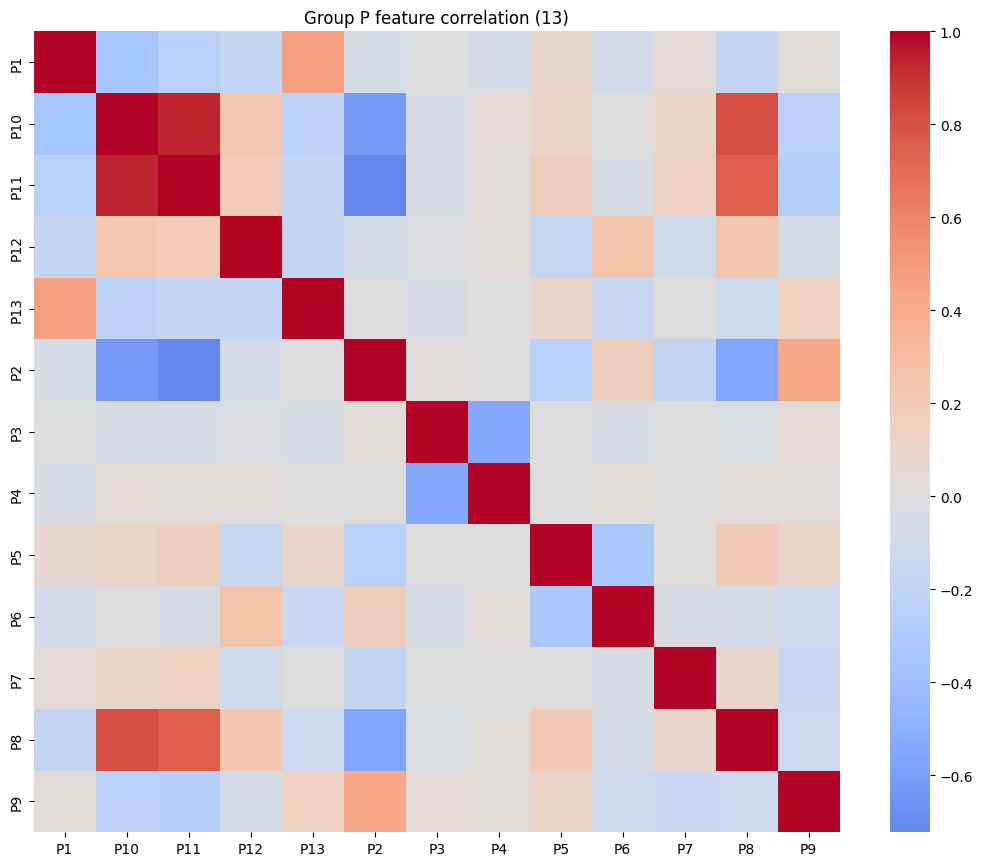


===== Group S: 12 num of feature =====


,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9
S1,1.000000,-0.044596,-0.063434,-0.031895,-0.039306,0.081240,-0.023699,-0.097651,-0.054862,0.185084,0.072398,-0.108155
S10,-0.044596,1.000000,0.916702,0.006922,0.076718,0.031373,0.820298,-0.001608,0.309512,-0.018937,-0.010148,-0.447178
S11,-0.063434,0.916702,1.000000,-0.020863,0.083967,0.033828,0.901187,-0.006836,0.363634,-0.017315,-0.020257,-0.505574
S12,-0.031895,0.006922,-0.020863,1.000000,-0.040124,-0.081304,-0.011526,-0.073778,-0.011987,-0.058987,-0.078373,0.030902
S2,-0.039306,0.076718,0.083967,-0.040124,1.000000,0.699894,0.097799,-0.146846,0.170692,-0.088398,0.646584,-0.082696
S3,0.081240,0.031373,0.033828,-0.081304,0.699894,1.000000,0.044052,-0.098534,0.114392,-0.118519,0.646900,-0.032157
S4,-0.023699,0.820298,0.901187,-0.011526,0.097799,0.044052,1.000000,-0.024386,0.461635,-0.046565,-0.047572,-0.493727
S5,-0.097651,-0.001608,-0.006836,-0.073778,-0.146846,-0.098534,-0.024386,1.000000,-0.000715,-0.085263,-0.106157,-0.028677
S6,-0.054862,0.309512,0.363634,-0.011987,0.170692,0.114392,0.461635,-0.000715,1.000000,-0.062905,-0.023986,-0.331261
S7,0.185084,-0.018937,-0.017315,-0.058987,-0.088398,-0.118519,-0.046565,-0.085263,-0.062905,1.000000,-0.108406,-0.078985


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



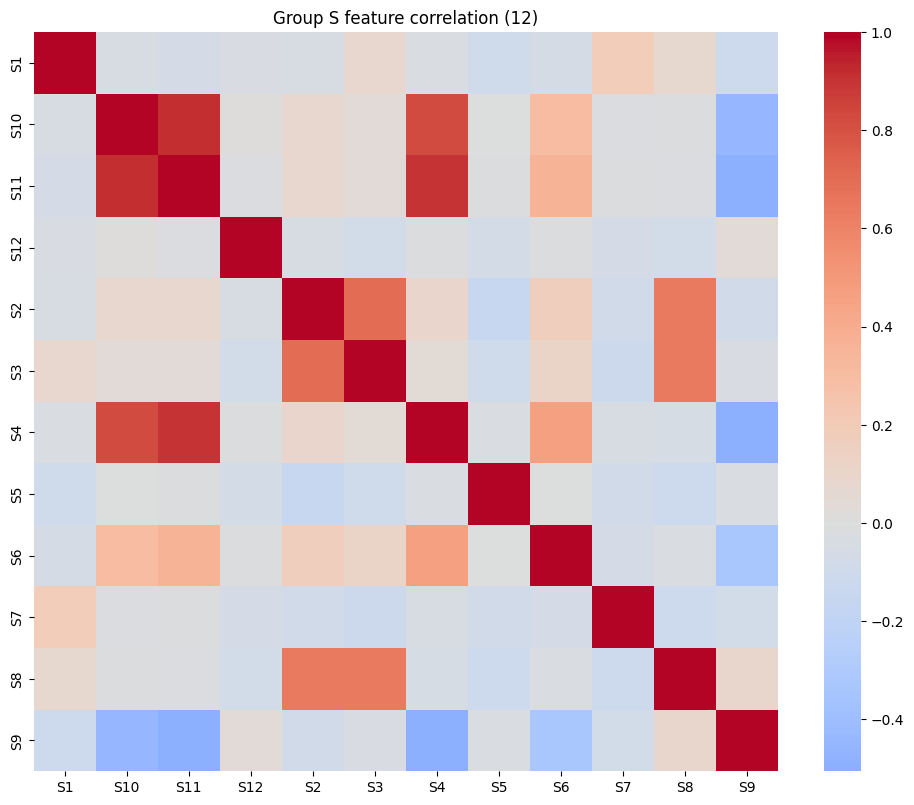


===== Group V: 13 num of feature =====


,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9
V1,1.000000,-0.126537,0.880568,0.443379,-0.087404,0.846583,0.804737,0.818938,0.107358,-0.440247,-0.073422,0.874316,-0.088272
V10,-0.126537,1.000000,-0.097660,-0.201334,0.717219,-0.145941,-0.148025,-0.167107,-0.325022,-0.065328,0.934170,-0.062070,0.985191
V11,0.880568,-0.097660,1.000000,0.499238,-0.060252,0.734874,0.749652,0.681318,0.097688,-0.337300,-0.055568,0.803121,-0.064054
V12,0.443379,-0.201334,0.499238,1.000000,-0.104558,0.460559,0.506417,0.375267,0.147718,0.227618,-0.159118,0.438717,-0.184989
V13,-0.087404,0.717219,-0.060252,-0.104558,1.000000,-0.096816,-0.092886,-0.119103,-0.166109,-0.033412,0.779232,-0.056917,0.747666
V2,0.846583,-0.145941,0.734874,0.460559,-0.096816,1.000000,0.793124,0.933699,0.161217,-0.334000,-0.125378,0.655576,-0.128232
V3,0.804737,-0.148025,0.749652,0.506417,-0.092886,0.793124,1.000000,0.711683,0.134280,-0.305056,-0.097381,0.644834,-0.115754
V4,0.818938,-0.167107,0.681318,0.375267,-0.119103,0.933699,0.711683,1.000000,0.167206,-0.390256,-0.142307,0.668769,-0.146494
V5,0.107358,-0.325022,0.097688,0.147718,-0.166109,0.161217,0.134280,0.167206,1.000000,0.114117,-0.351070,-0.007810,-0.338452
V6,-0.440247,-0.065328,-0.337300,0.227618,-0.033412,-0.334000,-0.305056,-0.390256,0.114117,1.000000,-0.094272,-0.389399,-0.092642


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



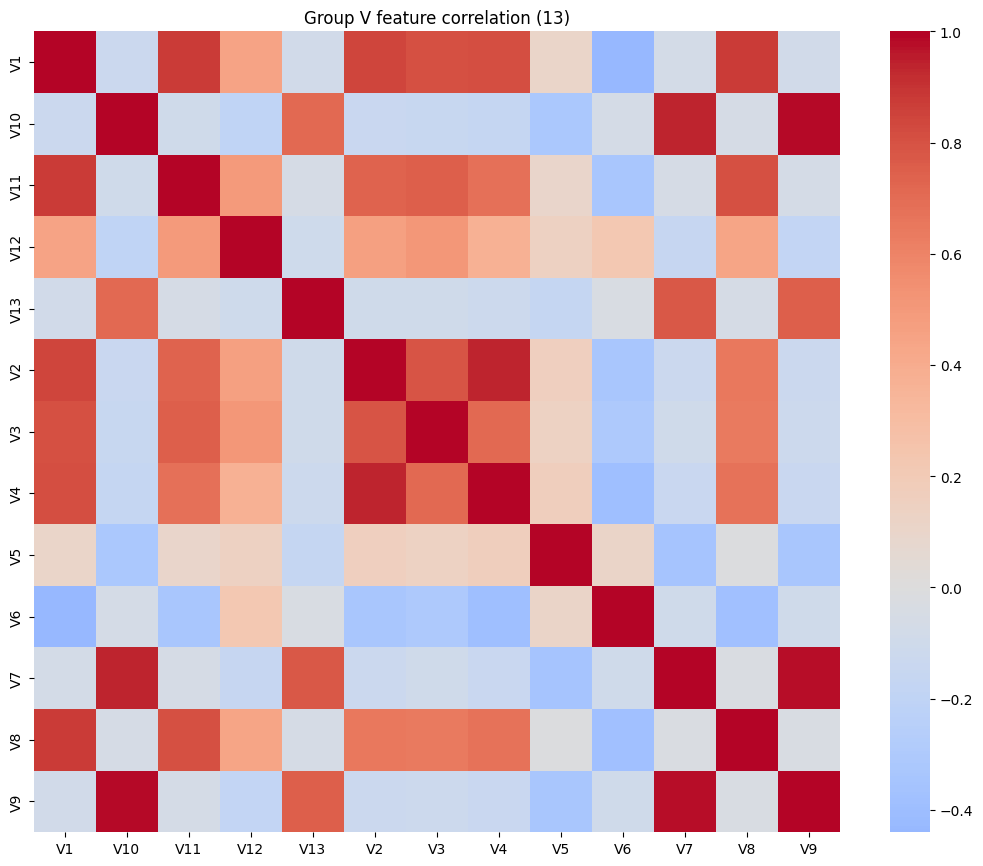

In [9]:
def show_group_corr(df,groups,use_z = False, max_cols_for_plot=20):
    """
    对每个 group 画特征间相关矩阵（数值 + 热力图）

    df      : 含特征数据的 DataFrame
    groups  : dict, 比如 {"V": ["V1","V2",...], "M": [...], ...}
    use_z   : 如果 True，则自动把列名加 "_z"（适合你已经做完标准化的情况）
    max_cols_for_plot : 如果一个 group 特征太多，只画前 N 个，避免图太大
    """
    for gname, cols in groups.items():
        # choose use origin or z
        if use_z:
            # 修正1: de.columns -> df.columns
            cols_use = [c + "_z" for c in cols if c + "_z" in df.columns]
        else:
            cols_use = [c for c in cols if c in df.columns]
            
        if len(cols_use) == 0:
            continue
            
        # date related matrix
        print(f"\n===== Group {gname}: {len(cols_use)} num of feature =====")
        
        # 修正2: dropna -> dropna() (这是导致报错的核心原因)
        sub = df[cols_use].dropna()
        
        corr_mat = sub.corr()
        display(corr_mat)
        
        # heat map
        # 修正3: plots_cols -> plot_cols (统一变量名)
        plot_cols = cols_use[:max_cols_for_plot]
        
        if len(plot_cols) == 0:
            continue

        plt.figure(figsize=(1.0 * len(plot_cols), 0.8 * len(plot_cols)))
        sns.heatmap(
            corr_mat.loc[plot_cols, plot_cols],
            cmap="coolwarm",
            center=0,
            annot=False
        )
        plt.title(f"Group {gname} feature correlation ({len(plot_cols)})")
        plt.show()

# 测试调用
show_group_corr(df, groups, use_z=False)
#show_group_corr(df, groups, use_z=True)
            
        
        
    

In [10]:
def select_representative_features(
    df,
    groups,
    target_col,
    use_z=False,
    max_per_group=3,
    corr_threshold=0.8,
):
    """
    在每个 group 内自动挑选“代表特征”：
    - 与目标相关度尽量高
    - 与已选特征的相关系数不能太高（避免信息重复）

    参数
    ----
    df : pd.DataFrame
        包含特征及目标的数据
    groups : dict
        形如 {"V": ["V1","V2",...], "M":["M1",...], ...} 的分组字典（用原始列名）
    target_col : str
        目标列名，例如 "market_forward_excess_returns" 或 "forward_returns"
    use_z : bool
        是否使用标准化后的列（即在原列名后加 "_z"）
    max_per_group : int
        每个 group 最多选择多少个代表特征
    corr_threshold : float
        新特征与已经选中任何一个特征的相关系数绝对值不得超过该阈值

    返回
    ----
    selected : dict
        形如 {"V": ["V3_z","V7_z",...], "M":["M5_z",...]} 的代表特征字典
    """
    selected = {}

    for gname, base_cols in groups.items():
        # 1. 决定本组用哪些列（原始 or _z 列）
        if use_z:
            cols = [c + "_z" for c in base_cols if c + "_z" in df.columns]
        else:
            cols = [c for c in base_cols if c in df.columns]

        if len(cols) == 0:
            continue

        print(f"\n===== Group {gname}：Candidate Features {len(cols)} =====")

        # 2. 取本组 + 目标，去掉 NaN
        sub = df[cols + [target_col]].dropna()

        # 3. 计算每个特征与目标的相关系数
        corr_to_y = sub.corr()[target_col].drop(target_col)

        # 4. 按 |corr| 从大到小排序
        ordered_features = corr_to_y.abs().sort_values(ascending=False).index.tolist()

        chosen = []

        for feat in ordered_features:
            # 已经选满就停
            if len(chosen) >= max_per_group:
                break

            # 如果还没选任何特征，第一个直接选
            if not chosen:
                chosen.append(feat)
                continue

            # 计算该候选特征与当前已选特征的相关系数最大值
            corr_mat = sub[chosen + [feat]].corr()
            corr_with_chosen = corr_mat.loc[feat, chosen].abs().max()

            # 如果与任何已选特征都不过分相似，就加入
            if corr_with_chosen < corr_threshold:
                chosen.append(feat)
            else:
                # 信息太重复，跳过
                # print(f"  skip {feat}: max corr with chosen = {corr_with_chosen:.2f}")
                pass

        selected[gname] = chosen

        print(f"Group {gname} 选中代表特征 {len(chosen)} 个：")
        for f in chosen:
            print(f"   {f} (corr_to_y = {corr_to_y[f]:.4f})")

    return selected


In [11]:
TARGET_COL = "market_forward_excess_returns"  # 或 "forward_returns"

selected_features = select_representative_features(
    df=df,
    groups=groups,
    target_col=TARGET_COL,
    use_z=False,          # 用 expanding 标准化后的特征
    max_per_group=5,     # 每组最多选 5 个代表
    corr_threshold=0.8,  # 与已选特征的 |corr| 必须 < 0.8 才能被选
)

print("\n=== final group represent features ===")
for g, feats in selected_features.items():
    print(g, ":", feats)



===== Group D：Candidate Features 9 =====
Group D 选中代表特征 5 个：
   D1 (corr_to_y = 0.0339)
   D8 (corr_to_y = 0.0247)
   D4 (corr_to_y = 0.0168)
   D5 (corr_to_y = 0.0166)
   D6 (corr_to_y = 0.0159)

===== Group E：Candidate Features 20 =====
Group E 选中代表特征 5 个：
   E3 (corr_to_y = -0.0526)
   E14 (corr_to_y = 0.0464)
   E20 (corr_to_y = -0.0452)
   E10 (corr_to_y = -0.0409)
   E7 (corr_to_y = -0.0322)

===== Group I：Candidate Features 9 =====
Group I 选中代表特征 5 个：
   I2 (corr_to_y = -0.0253)
   I1 (corr_to_y = -0.0062)
   I6 (corr_to_y = -0.0054)
   I3 (corr_to_y = 0.0046)
   I9 (corr_to_y = 0.0042)

===== Group M：Candidate Features 18 =====
Group M 选中代表特征 5 个：
   M3 (corr_to_y = 0.0511)
   M1 (corr_to_y = 0.0464)
   M4 (corr_to_y = -0.0315)
   M17 (corr_to_y = 0.0234)
   M12 (corr_to_y = -0.0193)

===== Group P：Candidate Features 13 =====
Group P 选中代表特征 5 个：
   P8 (corr_to_y = -0.0302)
   P12 (corr_to_y = -0.0235)
   P5 (corr_to_y = -0.0230)
   P7 (corr_to_y = -0.0217)
   P11 (corr_to_y = 

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

TARGET_COL = "market_forward_excess_returns"   # 或你当前用的 target
INFO_COLS = ["date_id", "forward_returns", "risk_free_rate", TARGET_COL]

# 保证按时间排序
df = df.sort_values("date_id").reset_index(drop=True)

# 按 date_id 切时间段
unique_dates = np.sort(df["date_id"].unique())
n_dates = len(unique_dates)

# 你可以自己调这三个数字
N_TEST  = 180          # 留给最后评估的天数
N_VALID = 180          # 用来比较组合的天数
# 剩下的就是 train
train_dates = unique_dates[:-(N_VALID + N_TEST)]
valid_dates = unique_dates[-(N_VALID + N_TEST):-N_TEST]
test_dates  = unique_dates[-N_TEST:]

train_mask = df["date_id"].isin(train_dates)
valid_mask = df["date_id"].isin(valid_dates)
test_mask  = df["date_id"].isin(test_dates)

print("n_dates:", n_dates)
print("train:", train_dates[0], "→", train_dates[-1], "  samples:", train_mask.sum())
print("valid:", valid_dates[0], "→", valid_dates[-1], "  samples:", valid_mask.sum())
print("test :", test_dates[0],  "→", test_dates[-1],  "  samples:", test_mask.sum())


n_dates: 9048
train: 0 → 8687   samples: 8688
valid: 8688 → 8867   samples: 180
test : 8868 → 9047   samples: 180


In [13]:
def compute_ic_on_mask(df, features, target_col, mask):
    
    # 这里记得用 copy() 以免影响原始 df，且处理 duplicates
    sub = df.loc[mask, features + [target_col]].dropna()
    
    # 如果 sub 里本身就有重复列，在这里去掉
    sub = sub.loc[:, ~sub.columns.duplicated()]
    
    ics = {}
    for f in features:
        # 如果 f 依然导致取出了 DataFrame (极少数情况)，强制转为 Series
        data_col = sub[f]
        if isinstance(data_col, pd.DataFrame):
            data_col = data_col.iloc[:, 0]
            
        # 避免常数列导致 spearman 报错
        if data_col.nunique() < 2:
            ics[f] = np.nan
            continue
            
        ic, _ = spearmanr(data_col, sub[target_col])
        ics[f] = ic
    
    ic_df = pd.Series(ics, name="IC").to_frame()
    ic_df["absIC"] = ic_df["IC"].abs()
    ic_df = ic_df.sort_values("absIC", ascending=False)
    return ic_df

In [14]:
ic_train = compute_ic_on_mask(df, all_feature_cols, TARGET_COL, train_mask)
ic_train.head(30)

,IC,absIC
P10,-0.083047,0.083047
M12,-0.064746,0.064746
P8,-0.060675,0.060675
E14,0.060304,0.060304
S4,0.056582,0.056582
M3,0.055871,0.055871
P1,0.055486,0.055486
E20,-0.055269,0.055269
E10,-0.053477,0.053477
S11,0.052767,0.052767


In [15]:
K_PER_GROUP = 4   # 每组挑几个

group_top_features = {}

for gname, cols in groups.items():
    # 只保留在 ic_train 里有结果的列
    valid_cols = [c for c in cols if c in ic_train.index]
    if not valid_cols:
        continue
    
    sub_ic = ic_train.loc[valid_cols].sort_values("absIC", ascending=False)
    top_k = sub_ic.head(K_PER_GROUP)
    group_top_features[gname] = list(top_k.index)

    print(f"\nGroup {gname}:")
    print(top_k)
    
print("\n=== group_top_features ===")
print(group_top_features)



Group D:
          IC     absIC
D6  0.030261  0.030261
D8  0.029724  0.029724
D7  0.028509  0.028509
D9  0.026253  0.026253

Group E:
           IC     absIC
E14  0.060304  0.060304
E20 -0.055269  0.055269
E10 -0.053477  0.053477
E8   0.051187  0.051187

Group I:
          IC     absIC
I2 -0.049500  0.049500
I4 -0.043831  0.043831
I3  0.037140  0.037140
I7  0.033627  0.033627

Group M:
           IC     absIC
M12 -0.064746  0.064746
M3   0.055871  0.055871
M8  -0.041975  0.041975
M1   0.039406  0.039406

Group P:
           IC     absIC
P10 -0.083047  0.083047
P8  -0.060675  0.060675
P1   0.055486  0.055486
P6  -0.040782  0.040782

Group S:
           IC     absIC
S4   0.056582  0.056582
S11  0.052767  0.052767
S10  0.047553  0.047553
S5   0.047135  0.047135

Group V:
           IC     absIC
V9   0.038986  0.038986
V10  0.038214  0.038214
V7   0.038198  0.038198
V13  0.036084  0.036084

=== group_top_features ===
{'D': ['D6', 'D8', 'D7', 'D9'], 'E': ['E14', 'E20', 'E10', 'E8'], 'I': [

In [16]:
FEATURES = ['D8', 'D7', 'D6', 'D9',
            'E14', 'E20', 'E10', 'E12',
            'I2', 'I4', 'I3', 'I7',
            'M12', 'M3', 'M8', 'M1',
            'P10', 'P8', 'P1', 'P6',
            'S4', 'S11', 'S5', 'S10',
            'V9', 'V10', 'V7', 'V13']

In [17]:
#Lagge value
lag_by_group = {
    'D': [1, 5, 21],
    'E': [1, 5, 21],
    'I': [1, 5, 21],
    'M': [1, 2, 5, 10, 21],
    'P': [1, 5, 21],
    'S': [1, 2, 5],
    'V': [1, 2, 5, 10, 21],
}
#set rolling windows
roll_windows_by_group = {
    'D': [21, 63],
    'E': [21, 63],
    'I': [21, 63],
    'M': [5, 21],
    'P': [21, 63],
    'S': [5, 21],
    'V': [5, 21, 63],
}
lag_cols = {}

for f in FEATURES:
    g = f[0]
    for L in lag_by_group[g]:
        lag_cols[f"{f}_lag{L}"] = df[f].shift(L)
df = pd.concat([df, pd.DataFrame(lag_cols, index=df.index)], axis=1)

#rolling features
roll_cols = {}
for f in FEATURES:
    g = f[0]
    for w in roll_windows_by_group[g]:
        roll_cols[f"{f}_roll_mean_{w}"] = df[f].rolling(w).mean()
        if g in ['M', 'V']:
            roll_cols[f"{f}_roll_std_{w}"] = df[f].rolling(w).std()
df = pd.concat([df, pd.DataFrame(roll_cols, index=df.index)], axis=1)

df.info()     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9048 entries, 0 to 9047
Columns: 372 entries, date_id to V13_roll_std_63
dtypes: float64(362), int64(10)
memory usage: 25.7 MB


**IC-filter + de-correlation snippet**

In [18]:

TARGET = "forward_returns"

# 1) Define candidate feature set
exclude_cols = ["date_id", TARGET, "risk_free_rate", "market_forward_excess_returns"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

# 2) Compute IC (Spearman) for each feature
ic_records = []
min_samples = 200   # skip features with too many NaNs

for col in feature_cols:
    tmp = df[[col, TARGET]].dropna()
    if len(tmp) < min_samples:
        continue
    ic, pval = spearmanr(tmp[col], tmp[TARGET])
    ic_records.append(
        {"feature": col, "ic": ic, "abs_ic": abs(ic), "pval": pval, "n": len(tmp)}
    )

ic_df = pd.DataFrame(ic_records).sort_values("abs_ic", ascending=False)
ic_df.head()

# 3) Filter by IC strength and significance
ic_thresh = 0.01   # you can tighten to 0.015 / 0.02
p_thresh = 0.05

keep_ic = ic_df[(ic_df["abs_ic"] >= ic_thresh) & (ic_df["pval"] <= p_thresh)]
selected = keep_ic["feature"].tolist()
print(f"Kept {len(selected)} features after IC filter.")

# 4) Remove highly collinear features (pairwise |corr| > 0.9
corr = df[selected].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
upper = upper.fillna(0.0)
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
final_features = [c for c in selected if c not in to_drop]

print(f"Final feature count after de-correlation: {len(final_features)}")
print(final_features[:]) 
#keep a DataFrame of IC stats for analysis
ic_clean = ic_df[ic_df["feature"].isin(final_features)]


Kept 87 features after IC filter.
Final feature count after de-correlation: 39
['V13_z', 'V10_roll_std_21', 'M4', 'M1_z', 'M1', 'M1_roll_std_5', 'V7_z', 'V10_lag2', 'V10_roll_std_5', 'S2', 'S5_lag2', 'M1_roll_std_21', 'S5_roll_mean_21', 'V10_roll_std_63', 'E19_z', 'V13_lag1', 'P5', 'S5', 'V10_z', 'V13_lag5', 'E11', 'D1', 'D6_z', 'V13_lag21', 'S12', 'M2', 'M3_lag5', 'I2_z', 'V13_roll_mean_63', 'M12_lag2', 'M17', 'D9_roll_mean_21', 'S6', 'S5_lag5', 'M12_z', 'M8', 'D8', 'E11_z', 'D6_lag5']


**Prepare dataset**

In [19]:
#ensure time order
df = df.sort_values("date_id").reset_index(drop=True)

use_cols = final_features + ["forward_returns", "date_id"]

df_model = df[use_cols].dropna().reset_index(drop=True)

print("Modeling sample size:", len(df_model))
#split dataset
split_ratio = 0.7
split_idx = int(len(df_model)*split_ratio)

train = df_model.iloc[:split_idx]
valid = df_model.iloc[split_idx:]
X_train = train[final_features].values
y_train = train["forward_returns"].values

X_valid = valid[final_features].values
y_valid = valid["forward_returns"].values

print("Train size:", X_train.shape, "Valid size:", X_valid.shape)

Modeling sample size: 2937
Train size: (2055, 39) Valid size: (882, 39)


**LGBM BASELINE**

In [20]:
import random

train_set = lgb.Dataset(X_train,label = y_train)
valid_set = lgb.Dataset(X_valid,label = y_valid )

def train_and_ic(params, X_train, y_train, X_valid, y_valid, num_boost_round=2000):
    train_set = lgb.Dataset(X_train, label=y_train)
    valid_set = lgb.Dataset(X_valid, label=y_valid)

    model = lgb.train(
        params,
        train_set,
        num_boost_round=num_boost_round,
        valid_sets=[valid_set],
        valid_names=["valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
        ],
    )

    y_pred = model.predict(X_valid, num_iteration=model.best_iteration)
    ic, _ = spearmanr(y_pred, y_valid)
    return ic, model

#random search 
param_space = {
    "learning_rate":  [0.01, 0.02, 0.03, 0.05],
    "num_leaves":     [31, 63, 127, 255],
    "min_data_in_leaf": [20, 50, 100, 200],
    "feature_fraction": [0.6, 0.8, 1.0],
    "bagging_fraction": [0.6, 0.8, 1.0],
    "bagging_freq":   [1, 5, 10],
}
N_TRIALS = 30
best_ic = -1.0
best_params = None
best_model = None

for t in range(N_TRIALS):
    # sample one combo
    params = {
        "objective": "regression",
        "metric": "mse",
        "verbosity": -1,
        "seed": 42 + t,  # different seed per trial
        "learning_rate":   random.choice(param_space["learning_rate"]),
        "num_leaves":      random.choice(param_space["num_leaves"]),
        "min_data_in_leaf":random.choice(param_space["min_data_in_leaf"]),
        "feature_fraction":random.choice(param_space["feature_fraction"]),
        "bagging_fraction":random.choice(param_space["bagging_fraction"]),
        "bagging_freq":    random.choice(param_space["bagging_freq"]),
    }

    ic, model = train_and_ic(params, X_train, y_train, X_valid, y_valid)
    print(f"Trial {t+1}/{N_TRIALS} | IC={ic:.4f} | params={params}")

    if ic > best_ic:
        best_ic = ic
        best_params = params
        best_model = model

print("\nBest valid IC:", best_ic)
print("Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Trial 1/30 | IC=0.0172 | params={'objective': 'regression', 'metric': 'mse', 'verbosity': -1, 'seed': 42, 'learning_rate': 0.01, 'num_leaves': 31, 'min_data_in_leaf': 20, 'feature_fraction': 0.8, 'bagging_fraction': 1.0, 'bagging_freq': 5}
Trial 2/30 | IC=0.0171 | params={'objective': 'regression', 'metric': 'mse', 'verbosity': -1, 'seed': 43, 'learning_rate': 0.05, 'num_leaves': 127, 'min_data_in_leaf': 200, 'feature_fraction': 0.8, 'bagging_fraction': 0.6, 'bagging_freq': 5}
Trial 3/30 | IC=-0.0058 | params={'objective': 'regression', 'metric': 'mse', 'verbosity': -1, 'seed': 44, 'learning_rate': 0.01, 'num_leaves': 63, 'min_data_in_leaf': 50, 'feature_fraction': 0.6, 'bagging_fraction': 1.0, 'bagging_freq': 5}
Trial 4/30 | IC=0.0435 | params={'objective': 'regression', 'metric': 'mse', 'verbosity': -1, 'seed': 45, 'learning_rate': 0.05, 'num_leaves': 63, 'min_data_in_leaf': 50, 'feature_fraction': 0.8, 'bagging_fraction': 1.0, 'bagging_freq': 1}
Trial 5/30 | IC=0.0326 | params={'obj

In [21]:
params = {
    "objective": "regression",
    "metric": "mse",
    "learning_rate": 0.01,
    "num_leaves": 127,
    "feature_fraction": 0.6,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_data_in_leaf": 20,
    "verbosity": -1,
    "seed": 42,
}

model = lgb.train(
    params,
    train_set,
    num_boost_round=2000,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100),
    ],
)

y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)
ic_valid, _ = spearmanr(y_pred_valid, y_valid)
print("Valid Spearman IC:", ic_valid)

Training until validation scores don't improve for 100 rounds
[100]	train's l2: 7.28679e-05	valid's l2: 0.00010243
Early stopping, best iteration is:
[43]	train's l2: 8.5962e-05	valid's l2: 0.000101943
Valid Spearman IC: 0.007667810359838356


**BUILD REGIME FEATURES**

Modeling sample size: 2937
Train size: 2055 Valid size: 882
[100]	valid's l2: 0.000102502

=== Baseline model (no regime) ===
Valid Spearman IC: 0.030000407504091654

=== Regime diagnostics (train) ===

Regime counts:
regime
0    1230
1      84
2     741
Name: count, dtype: int64

Regime proportion:
regime
0    0.599
1    0.041
2    0.361
Name: proportion, dtype: float64

State feature means by regime:
        V10_roll_std_21  V10_roll_std_63   V13_z   V10_z  V13_roll_mean_63  \
regime                                                                       
0                0.1471           0.2199 -0.4217  0.1586           -0.3671   
1                1.6026           2.5313  1.8975  4.7489            1.7881   
2                0.3425           0.5656  0.2548  1.4017            0.4104   

         E11_z   E19_z  
regime                  
0      -0.5443 -0.4951  
1      -0.5402  2.5783  
2      -0.5176  0.3944  

GMM means in state feature space:
   V10_roll_std_21  V10_roll_std_63   V13_z

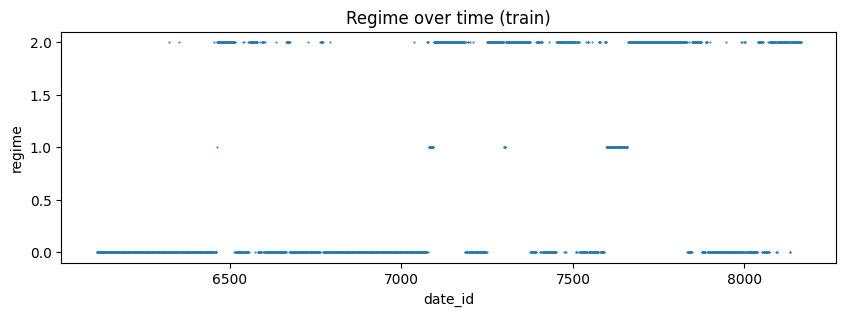

[100]	valid's l2: 0.000102464

=== Model with regime ===
Valid Spearman IC: 0.0011745299798836392

IC comparison:
  baseline IC: 0.030000407504091654
  regime   IC: 0.0011745299798836392


In [22]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# ==========================
# 0. build modeling dataset
# ==========================
df = df.sort_values("date_id").reset_index(drop=True)
use_cols = final_features + ["forward_returns", "date_id"]
df_model = df[use_cols].dropna().reset_index(drop=True)

print("Modeling sample size:", len(df_model))

# time split
split_ratio = 0.7
split_idx = int(len(df_model) * split_ratio)

train = df_model.iloc[:split_idx].copy()
valid = df_model.iloc[split_idx:].copy()

print("Train size:", len(train), "Valid size:", len(valid))

# ==========================
# 1. baseline LGBM (no regime)
# ==========================
X_train_base = train[final_features].values
y_train = train["forward_returns"].values

X_valid_base = valid[final_features].values
y_valid = valid["forward_returns"].values

params = {
    "objective": "regression",
    "metric": "mse",
    "learning_rate": 0.01,
    "num_leaves": 127,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.6,
    "bagging_fraction": 0.8,
    "bagging_freq": 10,
    "verbosity": -1,
    "seed": 57,
}

train_set_base = lgb.Dataset(X_train_base, label=y_train)
valid_set_base = lgb.Dataset(X_valid_base, label=y_valid)

model_base = lgb.train(
    params,
    train_set_base,
    num_boost_round=2000,
    valid_sets=[valid_set_base],
    valid_names=["valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)

y_pred_valid_base = model_base.predict(
    X_valid_base, num_iteration=model_base.best_iteration
)
ic_valid_base, _ = spearmanr(y_pred_valid_base, y_valid)
print("\n=== Baseline model (no regime) ===")
print("Valid Spearman IC:", ic_valid_base)

# ==========================
# 2. build regime feature (GMM)
# ==========================
state_features = [
    "V10_roll_std_21",
    "V10_roll_std_63",
    "V13_z",
    "V10_z",
    "V13_roll_mean_63",
    "E11_z",
    "E19_z",
]

missing = [c for c in state_features if c not in df_model.columns]
if missing:
    raise ValueError(f"Missing state features: {missing}")

X_state_train = train[state_features].values
X_state_valid = valid[state_features].values

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)
gmm.fit(X_state_train)

train_probs = gmm.predict_proba(X_state_train)
valid_probs = gmm.predict_proba(X_state_valid)

train["regime"] = train_probs.argmax(axis=1)
valid["regime"] = valid_probs.argmax(axis=1)

for k in range(gmm.n_components):
    train[f"regime_prob_{k}"] = train_probs[:, k]
    valid[f"regime_prob_{k}"] = valid_probs[:, k]

# diagnostics
print("\n=== Regime diagnostics (train) ===")
print("\nRegime counts:")
print(train["regime"].value_counts().sort_index())

print("\nRegime proportion:")
print(train["regime"].value_counts(normalize=True).sort_index().round(3))

print("\nState feature means by regime:")
print(
    train.groupby("regime")[state_features]
         .mean()
         .round(4)
)

print("\nGMM means in state feature space:")
print(pd.DataFrame(gmm.means_, columns=state_features).round(4))

plt.figure(figsize=(10, 3))
plt.plot(train["date_id"], train["regime"], ".", markersize=1)
plt.title("Regime over time (train)")
plt.xlabel("date_id")
plt.ylabel("regime")
plt.show()

# ==========================
# 3. LGBM with regime
# ==========================
features_regime = final_features + ["regime", "regime_prob_0", "regime_prob_1", "regime_prob_2"]
# or also include probabilities:
# features_regime = final_features + ["regime", "regime_prob_0", "regime_prob_1", "regime_prob_2"]

X_train_reg = train[features_regime].values
X_valid_reg = valid[features_regime].values

train_set_reg = lgb.Dataset(X_train_reg, label=y_train)
valid_set_reg = lgb.Dataset(X_valid_reg, label=y_valid)

model_reg = lgb.train(
    params,  # same params for fair comparison
    train_set_reg,
    num_boost_round=2000,
    valid_sets=[valid_set_reg],
    valid_names=["valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)

y_pred_valid_reg = model_reg.predict(
    X_valid_reg, num_iteration=model_reg.best_iteration
)
ic_valid_reg, _ = spearmanr(y_pred_valid_reg, y_valid)

print("\n=== Model with regime ===")
print("Valid Spearman IC:", ic_valid_reg)

print("\nIC comparison:")
print("  baseline IC:", ic_valid_base)
print("  regime   IC:", ic_valid_reg)


**Validate Regime Feature rubutness**

In [23]:
n_folds = 3  # you can change to 2 or 4
idx = np.linspace(0, len(df_model), n_folds + 1, dtype=int)
print("Fold boundaries:", idx)

baseline_ics = []
regime_ics = []

for k in range(n_folds):
    start = idx[k]
    end = idx[k + 1]

    # expanding window: train on [0, start), valid on [start, end)
    if start < 30:  # avoid too small train
        print(f"\nSkip fold {k} (train too short)")
        continue

    train = df_model.iloc[:start].copy()
    valid = df_model.iloc[start:end].copy()

    print(f"\n=== Fold {k+1}/{n_folds} ===")
    print("Train size:", len(train), "Valid size:", len(valid))

    # ------------------------------
    # A. baseline model (no regime)
    # ------------------------------
    X_train_base = train[final_features].values
    y_train = train["forward_returns"].values

    X_valid_base = valid[final_features].values
    y_valid = valid["forward_returns"].values

    train_set_base = lgb.Dataset(X_train_base, label=y_train)
    valid_set_base = lgb.Dataset(X_valid_base, label=y_valid)

    model_base = lgb.train(
        params,
        train_set_base,
        num_boost_round=2000,
        valid_sets=[valid_set_base],
        valid_names=["valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
        ],
    )

    y_pred_valid_base = model_base.predict(
        X_valid_base, num_iteration=model_base.best_iteration
    )
    ic_base, _ = spearmanr(y_pred_valid_base, y_valid)
    baseline_ics.append(ic_base)
    print("Fold baseline IC:", ic_base)

    # ------------------------------
    # B. build regime on this fold
    # ------------------------------
    X_state_train = train[state_features].values
    X_state_valid = valid[state_features].values

    gmm = GaussianMixture(
        n_components=3,
        covariance_type="full",
        random_state=42 + k,
    )
    gmm.fit(X_state_train)

    train_probs = gmm.predict_proba(X_state_train)
    valid_probs = gmm.predict_proba(X_state_valid)

    train["regime"] = train_probs.argmax(axis=1)
    valid["regime"] = valid_probs.argmax(axis=1)

    # if you want, you can also add prob features:
    # for j in range(gmm.n_components):
    #     train[f"regime_prob_{j}"] = train_probs[:, j]
    #     valid[f"regime_prob_{j}"] = valid_probs[:, j]

    features_regime = final_features + ["regime"]

    X_train_reg = train[features_regime].values
    X_valid_reg = valid[features_regime].values

    train_set_reg = lgb.Dataset(X_train_reg, label=y_train)
    valid_set_reg = lgb.Dataset(X_valid_reg, label=y_valid)

    model_reg = lgb.train(
        params,
        train_set_reg,
        num_boost_round=2000,
        valid_sets=[valid_set_reg],
        valid_names=["valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
        ],
    )

    y_pred_valid_reg = model_reg.predict(
        X_valid_reg, num_iteration=model_reg.best_iteration
    )
    ic_reg, _ = spearmanr(y_pred_valid_reg, y_valid)
    regime_ics.append(ic_reg)
    print("Fold regime  IC:", ic_reg)

# ==========================
# 2. summary of ICs
# ==========================
baseline_ics = np.array(baseline_ics)
regime_ics = np.array(regime_ics)

print("\n=== Time-series CV IC summary ===")
print("Baseline ICs by fold:", baseline_ics)
print("Regime   ICs by fold:", regime_ics)

print("\nBaseline mean IC:", baseline_ics.mean(), "std:", baseline_ics.std())
print("Regime   mean IC:", regime_ics.mean(), "std:", regime_ics.std())

Fold boundaries: [   0  979 1958 2937]

Skip fold 0 (train too short)

=== Fold 2/3 ===
Train size: 979 Valid size: 979
Fold baseline IC: 0.12331468737459488
Fold regime  IC: 0.13188373933243971

=== Fold 3/3 ===
Train size: 1958 Valid size: 979
Fold baseline IC: 0.02849030995542989
Fold regime  IC: 0.06110271211548332

=== Time-series CV IC summary ===
Baseline ICs by fold: [0.12331469 0.02849031]
Regime   ICs by fold: [0.13188374 0.06110271]

Baseline mean IC: 0.07590249866501238 std: 0.04741218870958249
Regime   mean IC: 0.09649322572396152 std: 0.0353905136084782


=== Top features (baseline, no regime) ===
E19_z              0.018729
V10_roll_std_5     0.017500
S5                 0.017337
P5                 0.015352
V13_lag21          0.014232
M1                 0.012653
V7_z               0.011775
V10_roll_std_63    0.010135
M4                 0.009572
S5_roll_mean_21    0.008412
M1_roll_std_21     0.008394
V13_lag5           0.008183
S12                0.007853
V10_lag2           0.007321
E11                0.007315
E11_z              0.006599
S5_lag2            0.006363
V13_lag1           0.006321
M1_z               0.005795
I2_z               0.005535
dtype: float64

=== Top features (with regime) ===
E19_z              0.028946
M1                 0.028611
V10_roll_std_5     0.025645
V13_lag21          0.019847
V13_lag1           0.015615
I2_z               0.013602
M4                 0.013116
D6_z               0.012890
M8                 0.012318
V13_z              0.011154
P5                 0.010094
S5_roll_mean_21    0.009913
M2        

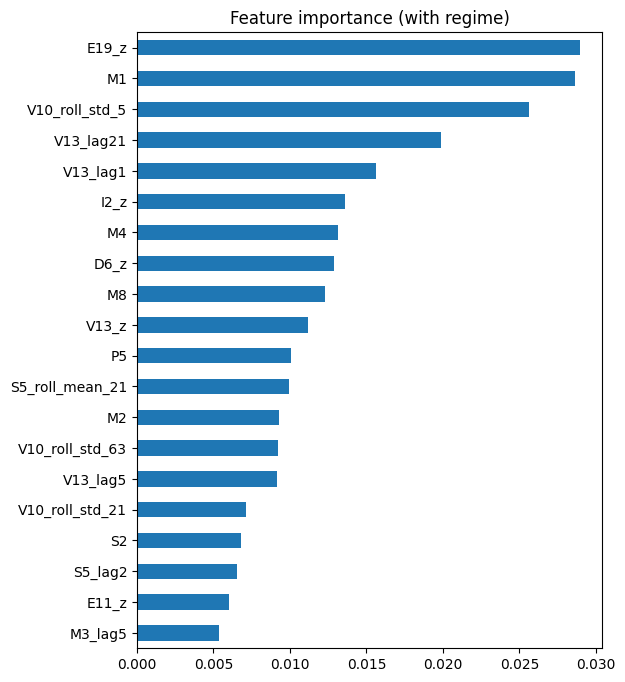

In [24]:
#check feature importance
imp_base = pd.Series(
    model_base.feature_importance(importance_type="gain"),
    index=final_features,
).sort_values(ascending=False)

print("=== Top features (baseline, no regime) ===")
print(imp_base.head(20))

print("\n=== Top features (with regime) ===")
imp_reg = pd.Series(
    model_reg.feature_importance(importance_type="gain"),
    index=features_regime,
).sort_values(ascending=False)
print(imp_reg.head(20))
topk = 20
imp_reg.head(topk).plot(kind="barh", figsize=(6, 8))
plt.gca().invert_yaxis()
plt.title("Feature importance (with regime)")
plt.show()

In [25]:
from sklearn.mixture import GaussianMixture
import numpy as np

# 1) state-defining features（跟你之前保持一致）
state_features = [
    "V10_roll_std_21",
    "V10_roll_std_63",
    "V13_z",
    "V10_z",
    "V13_roll_mean_63",
    "E11_z",
    "E19_z",
]

missing = [c for c in state_features if c not in df.columns]
if missing:
    raise ValueError(f"Missing state features in df: {missing}")

# 2) 只对这些列非 NaN 的行建模
X_state = df[state_features]
valid_idx = X_state.dropna().index
X_state_valid = X_state.loc[valid_idx].values

# 3) 拟合 GMM（简单版：用全部有效行拟合一次）
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
)
gmm.fit(X_state_valid)

probs = gmm.predict_proba(X_state_valid)
labels = probs.argmax(axis=1)

# 4) 把 regime 和 prob 都写回 df（其余 NaN 行先保持 NaN）
df["regime"] = np.nan
df.loc[valid_idx, "regime"] = labels

for k in range(gmm.n_components):
    col = f"regime_prob_{k}"
    df[col] = np.nan
    df.loc[valid_idx, col] = probs[:, k]

print("regime counts (including NaN):")
print(df["regime"].value_counts(dropna=False))



regime counts (including NaN):
regime
NaN    6111
0.0    1406
1.0    1200
2.0     331
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater




===== Running LGBM WITH REGIME =====

===== Running LGBM WITH REGIME+PROBS =====
Total samples: 2937
Num features: 43

=== Fold 1/5 ===
Train size: 492, Valid size: 489
Train dates: 6111 ~ 6602, Valid dates: 6603 ~ 7091
[100]	valid's l2: 4.04153e-05
Fold IC: 0.0818, MSE: 3.922759e-05, Sharpe: 0.453

=== Fold 2/5 ===
Train size: 981, Valid size: 489
Train dates: 6111 ~ 7091, Valid dates: 7092 ~ 7580
[100]	valid's l2: 7.88798e-05
Fold IC: 0.1522, MSE: 7.861732e-05, Sharpe: 1.174

=== Fold 3/5 ===
Train size: 1470, Valid size: 489
Train dates: 6111 ~ 7580, Valid dates: 7581 ~ 8069
[100]	valid's l2: 0.00016732
Fold IC: 0.0831, MSE: 1.624569e-04, Sharpe: 1.091

=== Fold 4/5 ===
Train size: 1959, Valid size: 489
Train dates: 6111 ~ 8069, Valid dates: 8070 ~ 8558
[100]	valid's l2: 0.000152651
Fold IC: 0.0609, MSE: 1.498511e-04, Sharpe: 0.035

=== Fold 5/5 ===
Train size: 2448, Valid size: 489
Train dates: 6111 ~ 8558, Valid dates: 8559 ~ 9047
[100]	valid's l2: 8.3415e-05
Fold IC: -0.0169, MS

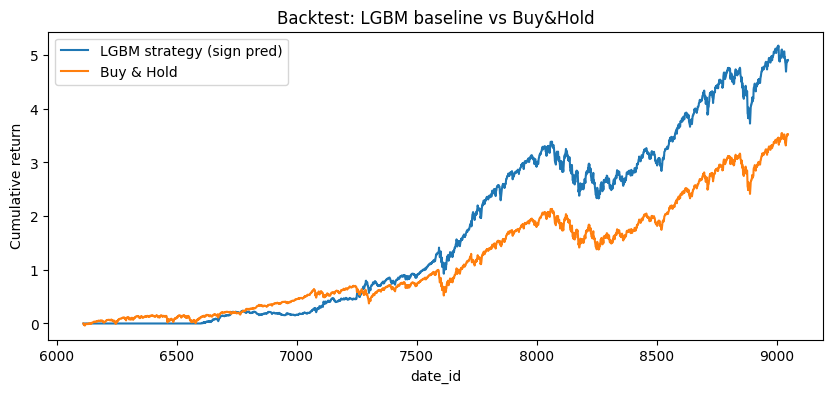


Top 20 feature importance (avg gain over folds):
E19_z              0.025716
M1                 0.022835
V13_lag1           0.017458
M12_lag2           0.016755
S5                 0.013338
V7_z               0.011953
regime_prob_1      0.011865
M2                 0.011828
V10_roll_std_5     0.011473
M1_z               0.011454
S2                 0.011451
M1_roll_std_21     0.010900
M12_z              0.010724
S5_lag2            0.009862
V13_lag5           0.009796
M1_roll_std_5      0.009269
V13_lag21          0.008724
S5_lag5            0.008417
S5_roll_mean_21    0.008132
M4                 0.007607
dtype: float64

===== REGIME+PROBS RESULTS =====
OOF IC: 0.06388938447148958
OOF Sharpe: 0.7492996832774658
Buy & Hold Sharpe: 0.6490436430834726

Top 20 Feature Importance:
E19_z              0.025716
M1                 0.022835
V13_lag1           0.017458
M12_lag2           0.016755
S5                 0.013338
V7_z               0.011953
regime_prob_1      0.011865
M2                 0

In [26]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
# ------------------------
# 工具函数：Sharpe
# ------------------------
def compute_sharpe(returns, rfr= 0.00010687852022525768, sf=252.0):
    r = np.asarray(returns)
    sr = sharpe_basic(r, rfr, sf)
    if np.isnan(sr):
        return np.nan

    # 样本偏度 / 峰度（excess kurtosis）
    s = skew(r)
    k = kurtosis(r, fisher=True)  # fisher=True => excess kurtosis (kurt-3)

    # 常见近似公式
    adj = sr * (1 + (s * sr) / 6 - (k * sr**2) / 24)
    return adj
#def compute_sharpe(returns, rfr= 0.00010687852022525768, sf=252.0):
#    mu = r.mean()
#    sigma = r.std()
#    if sigma == 0:
#        return np.nan
#    return np.sqrt(sf) * (mu - rfr) / sigma
def sharpe_basic(returns, rfr=0.0, sf=252.0):
    """
    Calculates the standard annualized Sharpe ratio.
    """
    r = np.asarray(returns)
    mu = np.nanmean(r)
    sigma = np.nanstd(r)
    
    if sigma == 0:
        return np.nan
    
    # Standard Sharpe Formula: sqrt(freq) * (mean - risk_free) / std
    return np.sqrt(sf) * (mu - rfr) / sigma    

# ------------------------
# 主函数：LGBM + TimeSeriesSplit CV
# ------------------------
def evaluate_lgbm_ts_cv(
    df,
    features,
    target_col="forward_returns",
    date_col="date_id",
    n_splits=5,
    lgb_params=None,
    plot_curves=True,
):
    # 1) sort & dropna
    df = df.sort_values(date_col).reset_index(drop=True)
    use_cols = features + [target_col, date_col]
    df_model = df[use_cols].dropna().reset_index(drop=True)
    X_all = df_model[features].values
    y_all = df_model[target_col].values
    dates = df_model[date_col].values

    print(f"Total samples: {len(df_model)}")
    print(f"Num features: {len(features)}")

    # default params
    if lgb_params is None:
        lgb_params = {
            "objective": "regression",
            "metric": "mse",
            "learning_rate": 0.01,
            "num_leaves": 127,
            "min_data_in_leaf": 20,
            "feature_fraction": 0.6,
            "bagging_fraction": 0.8,
            "bagging_freq": 10,
            "verbosity": -1,
            "seed": 57,
        }

    tscv = TimeSeriesSplit(n_splits=n_splits)
    oof_pred = np.zeros(len(df_model))

    fold_ics = []
    fold_mses = []
    fold_sharpes = []

    # 累积 feature importance（gain）
    feat_importance_sum = np.zeros(len(features))

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_all)):
        X_train, X_valid = X_all[train_idx], X_all[valid_idx]
        y_train, y_valid = y_all[train_idx], y_all[valid_idx]
        dtrain = lgb.Dataset(X_train, label=y_train)
        dvalid = lgb.Dataset(X_valid, label=y_valid)

        print(f"\n=== Fold {fold+1}/{n_splits} ===")
        print(f"Train size: {len(train_idx)}, Valid size: {len(valid_idx)}")
        print(
            f"Train dates: {dates[train_idx].min()} ~ {dates[train_idx].max()}, "
            f"Valid dates: {dates[valid_idx].min()} ~ {dates[valid_idx].max()}"
        )

        model = lgb.train(
            lgb_params,
            dtrain,
            num_boost_round=2000,
            valid_sets=[dvalid],
            valid_names=["valid"],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=100),
            ],
        )

        pred_valid = model.predict(
            X_valid, num_iteration=model.best_iteration
        )
        oof_pred[valid_idx] = pred_valid

        # per-fold metrics
        ic_fold, _ = spearmanr(pred_valid, y_valid)
        mse_fold = np.mean((pred_valid - y_valid) ** 2)
        fold_ics.append(ic_fold)
        fold_mses.append(mse_fold)

        # simple long/short strategy
        sig = np.sign(pred_valid)
        strat_ret = sig * y_valid
        sharpe_fold = compute_sharpe(strat_ret)
        fold_sharpes.append(sharpe_fold)

        print(f"Fold IC: {ic_fold:.4f}, MSE: {mse_fold:.6e}, Sharpe: {sharpe_fold:.3f}")

        # feature importance
        feat_importance_sum += model.feature_importance(importance_type="gain")

    # 2) OOF metrics
    print("\n=== OOF / 全样本评估 ===")
    ic_oof, _ = spearmanr(oof_pred, y_all)
    mse_oof = np.mean((oof_pred - y_all) ** 2)
    print(f"OOF IC:  {ic_oof:.4f}")
    print(f"OOF MSE: {mse_oof:.6e}")

    sig_oof = np.sign(oof_pred)
    strat_ret_oof = sig_oof * y_all
    sharpe_oof = compute_sharpe(strat_ret_oof)
    print(f"OOF strategy Sharpe: {sharpe_oof:.3f}")

    # buy&hold 对比
    bh_ret = y_all
    bh_sharpe = compute_sharpe(bh_ret)
    print(f"Buy&Hold Sharpe:      {bh_sharpe:.3f}")

    # 各折统计
    fold_ics = np.array(fold_ics)
    fold_mses = np.array(fold_mses)
    fold_sharpes = np.array(fold_sharpes)

    print("\nIC by fold:", fold_ics)
    print("IC mean:", fold_ics.mean(), "std:", fold_ics.std())
    print("\nSharpe by fold:", fold_sharpes)
    print("Sharpe mean:", fold_sharpes.mean(), "std:", fold_sharpes.std())

    # 3) 曲线
    if plot_curves:
        cum_strat = (1 + strat_ret_oof).cumprod() - 1
        cum_bh = (1 + bh_ret).cumprod() - 1

        plt.figure(figsize=(10, 4))
        plt.plot(dates, cum_strat, label="LGBM strategy (sign pred)")
        plt.plot(dates, cum_bh, label="Buy & Hold")
        plt.xlabel(date_col)
        plt.ylabel("Cumulative return")
        plt.title("Backtest: LGBM baseline vs Buy&Hold")
        plt.legend()
        plt.show()

    # 4) feature importance (平均 gain)
    feat_imp = pd.Series(feat_importance_sum / n_splits, index=features)
    feat_imp = feat_imp.sort_values(ascending=False)
    print("\nTop 20 feature importance (avg gain over folds):")
    print(feat_imp.head(20))

    # 返回所有有用的东西，方便你后续 ensemble / stacking
    result = {
        "df_model": df_model,
        "oof_pred": oof_pred,
        "y_all": y_all,
        "dates": dates,
        "fold_ics": fold_ics,
        "fold_mses": fold_mses,
        "fold_sharpes": fold_sharpes,
        "ic_oof": ic_oof,
        "mse_oof": mse_oof,
        "sharpe_oof": sharpe_oof,
        "bh_sharpe": bh_sharpe,
        "feature_importance": feat_imp,
    }
    return result
print("\n===== Running LGBM WITH REGIME =====")
features_regime = final_features + ["regime", "regime_prob_0", "regime_prob_1", "regime_prob_2"]

print("\n===== Running LGBM WITH REGIME+PROBS =====")
res_reg = evaluate_lgbm_ts_cv(
    df=df,
    features=features_regime,
    target_col="forward_returns",
    date_col="date_id",
    n_splits=5,
)

print("\n===== REGIME+PROBS RESULTS =====")
print("OOF IC:", res_reg["ic_oof"])
print("OOF Sharpe:", res_reg["sharpe_oof"])
print("Buy & Hold Sharpe:", res_reg["bh_sharpe"])
print("\nTop 20 Feature Importance:")
print(res_reg["feature_importance"].head(20))


**STACKING MODEL**
1. Data Prep & Splitting

In [29]:
import pandas as pd
import numpy as np
import pathlib
from sklearn.model_selection import TimeSeriesSplit

# ==========================================
# 1. 重新加载数据 (Reload Data)
# ==========================================
BASE_DIR = pathlib.Path("/kaggle/input/hull-tactical-market-prediction")
train_path = BASE_DIR / "train.csv"

# 读取数据
df = pd.read_csv(train_path)
df = df.sort_values("date_id").reset_index(drop=True)

# 定义列名
TARGET_COL = "market_forward_excess_returns"
INFO_COLS = ["date_id", "forward_returns", "risk_free_rate"]

# 提取原始特征列
original_feature_cols = [
    c for c in df.columns
    if c not in INFO_COLS + [TARGET_COL]
]

# ==========================================
# 2. 初始预处理 (Initial Preprocessing)
# ==========================================
def preprocess_basic(df, target_col):
    df_eng = df.copy()
    df_eng['group_id'] = 0  # 为 DL 模型添加 group_id
    
    # 生成 Target Lag (你之前的逻辑)
    lags = [1, 3, 5, 21, 64]
    for lag in lags:
        df_eng[f'target_lag_{lag}'] = df_eng.groupby('group_id')[target_col].shift(lag)
    
    # 生成 Rolling (你之前的逻辑)
    df_eng['target_rolling_mean_7'] = df_eng.groupby('group_id')[target_col] \
                                            .shift(1) \
                                            .rolling(window=7) \
                                            .mean()
    
    # 去除因 lag 产生的空值
    df_eng.dropna(subset=[f'target_lag_{max(lags)}'], inplace=True)
    return df_eng

processed_df = preprocess_basic(df, TARGET_COL)

# ==========================================
# 3. 恢复 train_df 和 test_df (Restore Split)
# ==========================================
split_idx = int(len(processed_df) * 0.8)
train_df = processed_df.iloc[:split_idx].reset_index(drop=True)
test_df = processed_df.iloc[split_idx:].reset_index(drop=True)

print("✅ 数据恢复成功！")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"Features: {len(original_feature_cols)}")

✅ 数据恢复成功！
Train shape: (7187, 105)
Test shape:  (1797, 105)
Features: 94


In [30]:
def ensure_regime_state_features(train_df, test_df):
    train_df = train_df.sort_values("date_id").reset_index(drop=True).copy()
    test_df  = test_df.sort_values("date_id").reset_index(drop=True).copy()

    # 合并做 rolling/z（rolling 用 shift(1)，合并不会引入未来泄露，因为 shift(1) 只用过去）
    df_all = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

    def roll_mean(col, w, mp=None):
        if mp is None: mp = max(2, w//3)
        return df_all[col].shift(1).rolling(w, min_periods=mp).mean()

    def roll_std(col, w, mp=None):
        if mp is None: mp = max(2, w//3)
        return df_all[col].shift(1).rolling(w, min_periods=mp).std()

    # ---- must-have raw columns ----
    must_raw = ["V10", "V13", "E11", "E19"]
    miss_raw = [c for c in must_raw if c not in df_all.columns]
    if miss_raw:
        raise ValueError(f"Missing raw cols required for regime FE: {miss_raw}")

    # ---- create missing roll features ----
    if "V10_roll_std_21" not in df_all.columns:
        df_all["V10_roll_std_21"] = roll_std("V10", 21, mp=7)
    if "V10_roll_std_63" not in df_all.columns:
        df_all["V10_roll_std_63"] = roll_std("V10", 63, mp=21)
    if "V13_roll_mean_63" not in df_all.columns:
        df_all["V13_roll_mean_63"] = roll_mean("V13", 63, mp=21)

    # ---- z-score features (use rolling 63 mean/std computed from past) ----
    def ensure_z(col):
        mean_col = f"{col}_roll_mean_63"
        std_col  = f"{col}_roll_std_63"
        if mean_col not in df_all.columns:
            df_all[mean_col] = roll_mean(col, 63, mp=21)
        if std_col not in df_all.columns:
            df_all[std_col]  = roll_std(col, 63, mp=21)
        z_col = f"{col}_z"
        if z_col not in df_all.columns:
            df_all[z_col] = (df_all[col] - df_all[mean_col]) / (df_all[std_col] + 1e-12)

    ensure_z("V10")
    ensure_z("V13")
    ensure_z("E11")
    ensure_z("E19")

    # 切回 train/test
    n_tr = len(train_df)
    train_df2 = df_all.iloc[:n_tr].reset_index(drop=True)
    test_df2  = df_all.iloc[n_tr:].reset_index(drop=True)

    # sanity
    needed = ["V10_roll_std_21","V10_roll_std_63","V13_roll_mean_63","V10_z","V13_z","E11_z","E19_z"]
    missing = [c for c in needed if c not in train_df2.columns]
    if missing:
        raise ValueError(f"Still missing after FE patch: {missing}")

    return train_df2, test_df2

train_df, test_df = ensure_regime_state_features(train_df, test_df)
print("✅ Regime state features ensured in train_df/test_df.")

# =====================================================
# White-list Data Fork (Leak-Safe, Stacking-Ready)
# =====================================================

# -------------------------
# 0. Global Definitions
# -------------------------
TARGET_COL = "market_forward_excess_returns"

# 所有“未来 / 标签相关”列 —— 严格禁止
FUTURE_COLS = [
    TARGET_COL,
    "forward_returns",
    "risk_free_rate"
]

# 元信息列
META_COLS = ["date_id", "group_id"]

# 原始官方特征（同步观测）
RAW_FEATURE_COLS = original_feature_cols.copy()

# Target 的自回归特征（你已生成）
TARGET_LAG_COLS = [
    "target_lag_1",
    "target_lag_3",
    "target_lag_5",
    "target_lag_21",
    "target_lag_64",
    "target_rolling_mean_7",
]

# 原始特征衍生的 lag / rolling（如果你生成过）
ENGINEERED_FEATURE_COLS = [
    c for c in train_df.columns
    if (
        c not in RAW_FEATURE_COLS
        and c not in FUTURE_COLS
        and c not in META_COLS
        and any(c.startswith(f"{raw}_") for raw in RAW_FEATURE_COLS)
    )
]

print("========== Feature Groups ==========")
print(f"RAW_FEATURE_COLS        : {len(RAW_FEATURE_COLS)}")
print(f"ENGINEERED_FEATURE_COLS : {len(ENGINEERED_FEATURE_COLS)}")
print(f"TARGET_LAG_COLS         : {len(TARGET_LAG_COLS)}")

# =====================================================
# 1. LGBM Data Fork (Tabular, Explicit History)
# =====================================================
LGBM_FEATURES = (
    RAW_FEATURE_COLS
    + ENGINEERED_FEATURE_COLS
    + TARGET_LAG_COLS
)

# 安全过滤（双保险）
LGBM_FEATURES = [
    c for c in LGBM_FEATURES
    if c in train_df.columns
    and c not in FUTURE_COLS
    and c not in META_COLS
]

model_inputs = {}

model_inputs["LGBM"] = {
    "X_train": train_df[LGBM_FEATURES],
    "y_train": train_df[TARGET_COL],
    "X_test":  test_df[LGBM_FEATURES]
}

print("\n[LGBM]")
print(f"Feature count: {len(LGBM_FEATURES)}")
print("Example:", LGBM_FEATURES[:5], "...", LGBM_FEATURES[-5:])

# =====================================================
# 2. PatchTST Data Fork (Pure Sequence, No Explicit Lag)
# =====================================================
PATCHTST_COLS = (
    META_COLS
    + [TARGET_COL]
    + RAW_FEATURE_COLS
)

PATCHTST_COLS = [
    c for c in PATCHTST_COLS
    if c in train_df.columns
    and c not in FUTURE_COLS
]

model_inputs["PatchTST"] = {
    "train": train_df[PATCHTST_COLS],
    "test":  test_df[PATCHTST_COLS]
}

print("\n[PatchTST]")
print(f"Input cols: {len(PATCHTST_COLS)}")
print("Example:", PATCHTST_COLS[:5], "...", PATCHTST_COLS[-5:])

# =====================================================
# 3. TFT Data Fork (Hybrid, Explicit Gating Signals)
# =====================================================
# TFT 推荐：
# - target 本身（历史序列）
# - 原始特征
# - 少量 target lag / rolling（作为条件信号）
# - 不要把 engineered feature 全塞进去，避免维度爆炸

TFT_COLS = (
    META_COLS
    + [TARGET_COL]
    + RAW_FEATURE_COLS
    + TARGET_LAG_COLS
)

TFT_COLS = [
    c for c in TFT_COLS
    if c in train_df.columns
    and c not in FUTURE_COLS
]

model_inputs["TFT"] = {
    "train": train_df[TFT_COLS],
    "test":  test_df[TFT_COLS]
}
print("\n[TFT]")
print(f"Input cols: {len(TFT_COLS)}")
print("Example:", TFT_COLS[:5], "...", TFT_COLS[-5:])
# =====================================================
# 4. N-BEATS (Sequence: usually univariate on target history)
# =====================================================
# A) Standard univariate N-BEATS: only needs target series + time index + group_id
NBEATS_COLS_UNIV = META_COLS + [TARGET_COL]
NBEATS_COLS_UNIV = [
    c for c in NBEATS_COLS_UNIV
    if c in train_df.columns and c not in FUTURE_COLS
]

model_inputs["NBEATS_univariate"] = {
    "train": train_df[NBEATS_COLS_UNIV],
    "test":  test_df[NBEATS_COLS_UNIV]
}

NBEATS_EXOG_COLS = []  # <- 你可以手动填，比如 RAW_FEATURE_COLS 的一个子集
NBEATS_COLS_EXOG = META_COLS + [TARGET_COL] + NBEATS_EXOG_COLS
NBEATS_COLS_EXOG = [
    c for c in NBEATS_COLS_EXOG
    if c in train_df.columns and c not in FUTURE_COLS
]
model_inputs["NBEATS_exog_optional"] = {
    "train": train_df[NBEATS_COLS_EXOG],
    "test":  test_df[NBEATS_COLS_EXOG]
}
print("\n[N-BEATS]")
print(f"Univariate cols: {len(NBEATS_COLS_UNIV)} -> {NBEATS_COLS_UNIV}")
print(f"Optional exog cols: {len(NBEATS_COLS_EXOG)} -> {NBEATS_COLS_EXOG}")


print("\n========== Data Fork Complete ==========")


✅ Regime state features ensured in train_df/test_df.
========== Feature Groups ==========
RAW_FEATURE_COLS        : 94
ENGINEERED_FEATURE_COLS : 13
TARGET_LAG_COLS         : 6

[LGBM]
Feature count: 113
Example: ['D1', 'D2', 'D3', 'D4', 'D5'] ... ['target_lag_3', 'target_lag_5', 'target_lag_21', 'target_lag_64', 'target_rolling_mean_7']

[PatchTST]
Input cols: 96
Example: ['date_id', 'group_id', 'D1', 'D2', 'D3'] ... ['V5', 'V6', 'V7', 'V8', 'V9']

[TFT]
Input cols: 102
Example: ['date_id', 'group_id', 'D1', 'D2', 'D3'] ... ['target_lag_3', 'target_lag_5', 'target_lag_21', 'target_lag_64', 'target_rolling_mean_7']

[N-BEATS]
Univariate cols: 2 -> ['date_id', 'group_id']
Optional exog cols: 2 -> ['date_id', 'group_id']

========== Data Fork Complete ==========


2. Level 1: Base Models
   **LightGBM**

In [31]:
# ============================================================
# Level-1 Base Model: LightGBM (OOF) with Adjusted Sharpe
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

import lightgbm as lgb


# -----------------------------
# 1) Strategy + Metrics Helpers
# -----------------------------

def _to_1d(a):
    if isinstance(a, (pd.Series, pd.DataFrame)):
        a = np.asarray(a).reshape(-1)
    return np.asarray(a).reshape(-1)

def newey_west_var(x, lag=5):
    """
    Newey-West HAC variance estimator for a 1D series x.
    Returns variance estimate (not std).
    """
    x = _to_1d(x)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 3:
        return np.nan
    x = x - x.mean()
    gamma0 = np.dot(x, x) / n
    var = gamma0
    L = int(lag)
    if L <= 0:
        return var
    for k in range(1, min(L, n - 1) + 1):
        w = 1.0 - k / (L + 1.0)  # Bartlett weights
        gamma_k = np.dot(x[k:], x[:-k]) / n
        var += 2.0 * w * gamma_k
    return var

def adjusted_sharpe(daily_rets, sf=252.0, nw_lag=5, eps=1e-12):
    """
    Adjusted Sharpe using Newey-West std (HAC) to handle autocorrelation.
    Sharpe_adj = mean / std_HAC * sqrt(sf)
    """
    r = _to_1d(daily_rets)
    r = r[~np.isnan(r)]
    if len(r) < 5:
        return np.nan
    mu = np.mean(r)
    var_hac = newey_west_var(r, lag=nw_lag)
    if (var_hac is None) or np.isnan(var_hac) or var_hac <= eps:
        return np.nan
    return (mu / np.sqrt(var_hac + eps)) * np.sqrt(sf)

def make_positions(pred, method="sign", threshold=0.0):
    """
    Convert predictions into positions.
    method:
      - "sign": position = sign(pred), optional threshold to set small preds to 0
      - "tanh": smooth position = tanh(pred / scale) (not used by default)
    """
    p = _to_1d(pred).copy()
    if method == "sign":
        if threshold > 0:
            p[np.abs(p) < threshold] = 0.0
        return np.sign(p)
    else:
        raise ValueError("Unsupported method")

def strategy_returns_from_preds(y_true, pred, date_id=None, position_method="sign", threshold=0.0):
    """
    y_true: target (future excess return)
    pred: model prediction
    date_id: optional, if multiple rows per date -> aggregate to daily PnL by mean
    Strategy: position * y_true
    """
    y = _to_1d(y_true)
    p = _to_1d(pred)
    pos = make_positions(p, method=position_method, threshold=threshold)
    pnl = pos * y

    if date_id is None:
        return pnl
    else:
        tmp = pd.DataFrame({"date_id": date_id, "pnl": pnl})
        # 如果一天有多条样本（panel），这里用 mean 代表“等权组合”
        daily = tmp.groupby("date_id", sort=True)["pnl"].mean()
        return daily.values

def compute_fold_metrics(y_true, pred, date_id=None, sf=252.0, nw_lag=5):
    """
    Return dict with:
      - adj_sharpe (main)
      - ic (Spearman)
      - mse
    """
    y = _to_1d(y_true)
    p = _to_1d(pred)

    # strategy daily returns
    daily_rets = strategy_returns_from_preds(y, p, date_id=date_id, position_method="sign", threshold=0.0)
    adj_sr = adjusted_sharpe(daily_rets, sf=sf, nw_lag=nw_lag)

    # Spearman IC
    ic = spearmanr(p, y, nan_policy="omit").correlation

    # MSE
    mse = mean_squared_error(y, p)

    return {"adj_sharpe": adj_sr, "ic": ic, "mse": mse}


# -----------------------------
# 2) Training: LGBM OOF
# -----------------------------

def train_lgbm_oof(
    X_train, y_train, X_test,
    date_id_train=None,  # for daily pnl aggregation (optional)
    n_splits=5,
    seed=42,
    sf=252.0,
    nw_lag=5,
    early_stopping_rounds=200,
    verbose_eval=200
):
    """
    Train LightGBM with TimeSeriesSplit, produce OOF preds + averaged test preds.
    Main model selection / reporting metric = adjusted Sharpe ratio.
    """
    Xtr = X_train.reset_index(drop=True)
    ytr = pd.Series(y_train).reset_index(drop=True)
    Xte = X_test.reset_index(drop=True)

    if date_id_train is not None:
        date_id_train = pd.Series(date_id_train).reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits=n_splits)

    oof_pred = np.full(len(Xtr), np.nan, dtype=float)
    test_pred_folds = []
    fold_metrics = []
    models = []

    # A reasonably strong baseline config (safe + stable)
    params = dict(
        objective="regression",
        metric="l2",
        learning_rate=0.02,
        n_estimators=20000,
        num_leaves=64,
        min_child_samples=200,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=5.0,
        max_depth=-1,
        random_state=seed,
        n_jobs=-1
    )

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(Xtr), 1):
        X_tr, X_va = Xtr.iloc[tr_idx], Xtr.iloc[va_idx]
        y_tr, y_va = ytr.iloc[tr_idx], ytr.iloc[va_idx]

        model = lgb.LGBMRegressor(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="l2",
            callbacks=[
                lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False),
                lgb.log_evaluation(period=verbose_eval)
            ]
        )

        # valid preds
        pred_va = model.predict(X_va, num_iteration=model.best_iteration_)
        oof_pred[va_idx] = pred_va

        # fold metrics (main = adj Sharpe)
        did_va = None if date_id_train is None else date_id_train.iloc[va_idx]
        m = compute_fold_metrics(y_va.values, pred_va, date_id=did_va, sf=sf, nw_lag=nw_lag)
        m["fold"] = fold
        m["best_iter"] = getattr(model, "best_iteration_", None)
        fold_metrics.append(m)

        # test preds
        pred_te = model.predict(Xte, num_iteration=model.best_iteration_)
        test_pred_folds.append(pred_te)

        models.append(model)

        print(f"[Fold {fold}] adjSharpe={m['adj_sharpe']:.4f} | IC={m['ic']:.4f} | MSE={m['mse']:.6g} | best_iter={m['best_iter']}")

    # average test preds
    test_pred = np.mean(np.vstack(test_pred_folds), axis=0)

    # overall OOF metrics
    valid_mask = ~np.isnan(oof_pred)
    overall = compute_fold_metrics(
        ytr.values[valid_mask],
        oof_pred[valid_mask],
        date_id=None if date_id_train is None else date_id_train.values[valid_mask],
        sf=sf,
        nw_lag=nw_lag
    )

    return oof_pred, test_pred, pd.DataFrame(fold_metrics), overall, models


# -----------------------------
# 3) Run (expects your whitelist forks exist)
# -----------------------------
# Requires:
#   model_inputs["LGBM"]["X_train"], ["y_train"], ["X_test"]
# Optional:
#   train_df["date_id"] for daily aggregation (if multiple rows per date)
X_train = model_inputs["LGBM"]["X_train"]
y_train = model_inputs["LGBM"]["y_train"]
X_test  = model_inputs["LGBM"]["X_test"]

date_id_train = train_df["date_id"]  # safe to use for aggregation; not a feature

oof_pred_lgbm, test_pred_lgbm, fold_metrics_lgbm, overall_oof_lgbm, lgbm_models = train_lgbm_oof(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    date_id_train=date_id_train,
    n_splits=5,          # 你可以先用 3 跑通，再提高到 5 或更多
    seed=42,
    sf=252.0,
    nw_lag=5,            # adjusted Sharpe 的 Newey-West lag
    early_stopping_rounds=300,
    verbose_eval=200
)

print("\n========== LGBM OOF Summary ==========")
print("Overall OOF adjusted Sharpe:", overall_oof_lgbm["adj_sharpe"])
print("Overall OOF IC            :", overall_oof_lgbm["ic"])
print("Overall OOF MSE           :", overall_oof_lgbm["mse"])

display(fold_metrics_lgbm)

# 存起来给 stacking 用
base_preds = {}
base_preds["LGBM"] = {
    "oof": oof_pred_lgbm,
    "test": test_pred_lgbm,
    "fold_metrics": fold_metrics_lgbm,
    "overall": overall_oof_lgbm
}


[200]	valid_0's l2: 0.000103831
[Fold 1] adjSharpe=0.5979 | IC=0.0684 | MSE=0.000103414 | best_iter=87
[200]	valid_0's l2: 0.000169135
[400]	valid_0's l2: 0.000171512
[Fold 2] adjSharpe=1.3087 | IC=0.0862 | MSE=0.000168616 | best_iter=120
[200]	valid_0's l2: 0.000149078
[Fold 3] adjSharpe=0.6960 | IC=0.0372 | MSE=0.000144944 | best_iter=3
[200]	valid_0's l2: 0.000119115
[Fold 4] adjSharpe=-0.2483 | IC=0.0562 | MSE=0.000113957 | best_iter=9
[200]	valid_0's l2: 6.27668e-05
[Fold 5] adjSharpe=1.6480 | IC=0.0855 | MSE=6.08325e-05 | best_iter=15

========== LGBM OOF Summary ==========
Overall OOF adjusted Sharpe: 0.7573603402870037
Overall OOF IC            : 0.0566253412471034
Overall OOF MSE           : 0.00011835275209986949


,adj_sharpe,ic,mse,fold,best_iter
0,0.597915,0.068353,0.000103,1,87
1,1.308707,0.086247,0.000169,2,120
2,0.696023,0.037202,0.000145,3,3
3,-0.248258,0.056156,0.000114,4,9
4,1.648006,0.085479,0.000061,5,15


In [33]:
import numpy as np
import pandas as pd

TARGET_COL = "market_forward_excess_returns"

def add_target_regime_states_v2(train_df, test_df, target_col=TARGET_COL):
    train_df = train_df.sort_values("date_id").reset_index(drop=True).copy()
    test_df  = test_df.sort_values("date_id").reset_index(drop=True).copy()
    df_all = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

    y = df_all[target_col].astype(float)

    def rmean(s, w, mp): return s.shift(1).rolling(w, min_periods=mp).mean()
    def rstd(s, w, mp):  return s.shift(1).rolling(w, min_periods=mp).std()

    df_all["tgt_vol_21"] = rstd(y, 21, mp=5)
    df_all["tgt_vol_63"] = rstd(y, 63, mp=10)
    df_all["tgt_mom_21"] = rmean(y, 21, mp=5)
    df_all["tgt_mom_63"] = rmean(y, 63, mp=10)

    df_all["tgt_vol_ratio"] = df_all["tgt_vol_21"] / (df_all["tgt_vol_63"] + 1e-12)

    # trend persistence: fraction of positive returns in last 21 days (past only)
    df_all["tgt_pos_frac_21"] = (y.shift(1) > 0).rolling(21, min_periods=5).mean()

    n_tr = len(train_df)
    train_out = df_all.iloc[:n_tr].reset_index(drop=True)
    test_out  = df_all.iloc[n_tr:].reset_index(drop=True)
    return train_out, test_out

# ---- RUN ----
train_v2, test_v2 = add_target_regime_states_v2(train_df, test_df)

state_features_v2 = ["tgt_vol_21","tgt_vol_63","tgt_mom_21","tgt_mom_63","tgt_vol_ratio","tgt_pos_frac_21"]

print("[NaN rate of new state features]")
print(train_v2[state_features_v2].isna().mean().sort_values(ascending=False))

print("\n[Head 30]")
print(train_v2[state_features_v2].head(30))



[NaN rate of new state features]
tgt_vol_63         0.001391
tgt_mom_63         0.001391
tgt_vol_ratio      0.001391
tgt_vol_21         0.000696
tgt_mom_21         0.000696
tgt_pos_frac_21    0.000557
dtype: float64

[Head 30]
    tgt_vol_21  tgt_vol_63  tgt_mom_21  tgt_mom_63  tgt_vol_ratio  \
0          NaN         NaN         NaN         NaN            NaN   
1          NaN         NaN         NaN         NaN            NaN   
2          NaN         NaN         NaN         NaN            NaN   
3          NaN         NaN         NaN         NaN            NaN   
4          NaN         NaN         NaN         NaN            NaN   
5     0.004332         NaN   -0.001396         NaN            NaN   
6     0.003879         NaN   -0.001325         NaN            NaN   
7     0.004638         NaN   -0.000193         NaN            NaN   
8     0.004305         NaN   -0.000084         NaN            NaN   
9     0.004032         NaN   -0.000150         NaN            NaN   
10    0.005324

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



In [36]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import pandas as pd

def make_regime_features_oof(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    state_features,
    n_components=3,
    n_splits=5,
    random_state=42,
    min_fit_rows=200,
):
    # --- sanity ---
    for c in state_features:
        if c not in train_df.columns:
            raise ValueError(f"Missing state feature in train_df: {c}")
        if c not in test_df.columns:
            raise ValueError(f"Missing state feature in test_df: {c}")

    train_df = train_df.sort_values("date_id").reset_index(drop=True).copy()
    test_df  = test_df.sort_values("date_id").reset_index(drop=True).copy()

    # OOF containers
    oof_regime = np.full(len(train_df), np.nan)
    oof_probs  = np.full((len(train_df), n_components), np.nan)

    tscv = TimeSeriesSplit(n_splits=n_splits)

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(train_df), 1):
        X_tr = train_df.loc[tr_idx, state_features]
        X_va = train_df.loc[va_idx, state_features]

        tr_valid = X_tr.dropna().index
        if len(tr_valid) < min_fit_rows:
            print(f"[Fold {fold}] WARNING: too few valid rows for GMM fit: {len(tr_valid)}")
            continue

        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type="full",
            random_state=random_state
        )
        gmm.fit(X_tr.loc[tr_valid].values)

        va_valid = X_va.dropna().index
        if len(va_valid) == 0:
            print(f"[Fold {fold}] valid has 0 non-NaN rows for regime.")
            continue

        probs = gmm.predict_proba(X_va.loc[va_valid].values)
        labels = probs.argmax(axis=1)

        oof_probs[va_valid, :] = probs
        oof_regime[va_valid] = labels

        print(f"[Fold {fold}] fitted on {len(tr_valid)} rows, predicted {len(va_valid)} rows")

    # write back OOF to train
    train_out = train_df.copy()
    train_out["regime"] = oof_regime
    for k in range(n_components):
        train_out[f"regime_prob_{k}"] = oof_probs[:, k]

    # train-full fit -> test transform
    X_full = train_df[state_features]
    full_valid = X_full.dropna().index
    if len(full_valid) < min_fit_rows:
        print(f"[TrainFull] WARNING: too few valid rows for GMM fit: {len(full_valid)}")

    gmm_full = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=random_state
    )
    gmm_full.fit(X_full.loc[full_valid].values)

    X_test = test_df[state_features]
    test_valid = X_test.dropna().index
    test_probs = np.full((len(test_df), n_components), np.nan)
    test_regime = np.full(len(test_df), np.nan)

    if len(test_valid) > 0:
        probs = gmm_full.predict_proba(X_test.loc[test_valid].values)
        labels = probs.argmax(axis=1)
        test_probs[test_valid, :] = probs
        test_regime[test_valid] = labels

    test_out = test_df.copy()
    test_out["regime"] = test_regime
    for k in range(n_components):
        test_out[f"regime_prob_{k}"] = test_probs[:, k]

    return train_out, test_out


In [37]:
train_df_reg2, test_df_reg2 = make_regime_features_oof(
    train_df=train_v2,
    test_df=test_v2,
    state_features=state_features_v2,
    n_components=3,
    n_splits=5,
    random_state=42
)

print("\n[Train OOF regime counts]")
print(pd.Series(train_df_reg2["regime"]).value_counts(dropna=False))

print("\n[Train OOF prob NaN rate]")
print(train_df_reg2[[f"regime_prob_{k}" for k in range(3)]].isna().mean())

print("\n[Test regime counts]")
print(pd.Series(test_df_reg2["regime"]).value_counts(dropna=False))


[Fold 1] fitted on 1192 rows, predicted 1197 rows
[Fold 2] fitted on 2389 rows, predicted 1197 rows
[Fold 3] fitted on 3586 rows, predicted 1197 rows
[Fold 4] fitted on 4783 rows, predicted 1197 rows
[Fold 5] fitted on 5980 rows, predicted 1197 rows

[Train OOF regime counts]
regime
0.0    2448
2.0    2134
1.0    1403
NaN    1202
Name: count, dtype: int64

[Train OOF prob NaN rate]
regime_prob_0    0.167246
regime_prob_1    0.167246
regime_prob_2    0.167246
dtype: float64

[Test regime counts]
regime
0.0    1259
1.0     292
2.0     246
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



In [48]:
# =====================================================
# Fix NaN in regime_prob (neutral fill)
# =====================================================

prob_cols = ["regime_prob_0", "regime_prob_1", "regime_prob_2"]

print("[Before fillna]")
print(train_df_reg2[prob_cols].isna().mean())

train_df_reg2[prob_cols] = train_df_reg2[prob_cols].fillna(1/3)
test_df_reg2[prob_cols]  = test_df_reg2[prob_cols].fillna(1/3)

print("\n[After fillna]")
print(train_df_reg2[prob_cols].isna().mean())


[Before fillna]
regime_prob_0    0.167246
regime_prob_1    0.167246
regime_prob_2    0.167246
dtype: float64

[After fillna]
regime_prob_0    0.0
regime_prob_1    0.0
regime_prob_2    0.0
dtype: float64


In [49]:
# ============================================================
# LGBM with (final_features + regime_prob_0..2) on train_df_reg/test_df_reg
# Requires: train_lgbm_oof() already defined in notebook
# ============================================================

# ---- Use train_df_reg2/test_df_reg2 for LGBM ----
train_df2 = train_df_reg2.copy()
test_df2  = test_df_reg2.copy()

assert "final_features" in globals(), "final_features not found."

final_feats = [c for c in final_features if (c in train_df2.columns and c in test_df2.columns)]
REGIME_PROB_COLS = [c for c in ["regime_prob_0","regime_prob_1","regime_prob_2"] if (c in train_df2.columns and c in test_df2.columns)]

LGBM_FEATURES = final_feats + REGIME_PROB_COLS
LGBM_FEATURES = [c for c in LGBM_FEATURES if c not in ["date_id","group_id",TARGET_COL,"forward_returns","risk_free_rate"]]

X_train = train_df2[LGBM_FEATURES]
y_train = train_df2[TARGET_COL]
X_test  = test_df2[LGBM_FEATURES]
date_id_train = train_df2["date_id"]

oof_pred_lgbm, test_pred_lgbm, fold_metrics_lgbm, overall_oof_lgbm, lgbm_models = train_lgbm_oof(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    date_id_train=date_id_train,
    n_splits=5,
    seed=57,
    sf=252.0,
    nw_lag=5,
    early_stopping_rounds=300,
    verbose_eval=200
)

print("\n========== LGBM OOF Summary (NEW metric) ==========")
print("Overall OOF adjusted Sharpe:", overall_oof_lgbm["adj_sharpe"])
print("Overall OOF IC            :", overall_oof_lgbm["ic"])
print("Overall OOF MSE           :", overall_oof_lgbm["mse"])
display(fold_metrics_lgbm)

base_preds = base_preds if "base_preds" in globals() else {}
base_preds["LGBM_final_plus_target_regimeprob"] = {
    "oof": oof_pred_lgbm,
    "test": test_pred_lgbm,
    "fold_metrics": fold_metrics_lgbm,
    "overall": overall_oof_lgbm,
    "features": LGBM_FEATURES,
    "note": "final_features + regime_prob_0..2 (target-based GMM, OOF-safe)"
}
print("✅ saved:", "LGBM_final_plus_target_regimeprob")


[200]	valid_0's l2: 0.000103828
[400]	valid_0's l2: 0.0001036
[600]	valid_0's l2: 0.000103485
[800]	valid_0's l2: 0.000103243
[1000]	valid_0's l2: 0.000103096
[1200]	valid_0's l2: 0.000103093
[1400]	valid_0's l2: 0.000102924
[1600]	valid_0's l2: 0.000102821
[1800]	valid_0's l2: 0.000102795
[2000]	valid_0's l2: 0.000102755
[2200]	valid_0's l2: 0.000102739
[2400]	valid_0's l2: 0.000102663
[2600]	valid_0's l2: 0.000102659
[2800]	valid_0's l2: 0.000102599
[Fold 1] adjSharpe=0.4547 | IC=0.0722 | MSE=0.000102637 | best_iter=2674
[200]	valid_0's l2: 0.000169927
[Fold 2] adjSharpe=0.8440 | IC=0.0569 | MSE=0.000169272 | best_iter=36
[200]	valid_0's l2: 0.000146323
[Fold 3] adjSharpe=0.5155 | IC=0.0333 | MSE=0.000144817 | best_iter=44
[200]	valid_0's l2: 0.000114596
[Fold 4] adjSharpe=0.4019 | IC=0.0291 | MSE=0.000113928 | best_iter=21
[200]	valid_0's l2: 6.17899e-05
[Fold 5] adjSharpe=0.8408 | IC=0.0945 | MSE=6.08299e-05 | best_iter=36

========== LGBM OOF Summary (NEW metric) ==========
Overal

,adj_sharpe,ic,mse,fold,best_iter
0,0.454733,0.072197,0.000103,1,2674
1,0.844012,0.056890,0.000169,2,36
2,0.515486,0.033286,0.000145,3,44
3,0.401885,0.029140,0.000114,4,21
4,0.840814,0.094535,0.000061,5,36


✅ saved: LGBM_final_plus_target_regimeprob


In [50]:
# A) no regime probs
trainA, testA = train_df_reg2.copy(), test_df_reg2.copy()
X_train_A = trainA[[c for c in final_features if c in trainA.columns]]
y_train_A = trainA[TARGET_COL]
X_test_A  = testA[[c for c in final_features if c in testA.columns]]

oofA, testA_pred, fmA, overallA, _ = train_lgbm_oof(
    X_train=X_train_A, y_train=y_train_A, X_test=X_test_A,
    date_id_train=trainA["date_id"],
    n_splits=5, seed=57, sf=252.0, nw_lag=5,
    early_stopping_rounds=300, verbose_eval=200
)

# B) + regime probs
REGIME_PROB_COLS = ["regime_prob_0","regime_prob_1","regime_prob_2"]
X_train_B = trainA[[c for c in final_features if c in trainA.columns] + REGIME_PROB_COLS]
X_test_B  = testA[[c for c in final_features if c in testA.columns] + REGIME_PROB_COLS]

oofB, testB_pred, fmB, overallB, _ = train_lgbm_oof(
    X_train=X_train_B, y_train=y_train_A, X_test=X_test_B,
    date_id_train=trainA["date_id"],
    n_splits=5, seed=57, sf=252.0, nw_lag=5,
    early_stopping_rounds=300, verbose_eval=200
)

print("\nA) final_features only:", overallA)
print("B) + regime_prob:", overallB)
display(pd.DataFrame({
    "fold": fmA["fold"],
    "A_adj_sharpe": fmA["adj_sharpe"],
    "B_adj_sharpe": fmB["adj_sharpe"],
    "A_ic": fmA["ic"],
    "B_ic": fmB["ic"],
    "A_best_iter": fmA["best_iter"],
    "B_best_iter": fmB["best_iter"],
}))


[200]	valid_0's l2: 0.000103828
[400]	valid_0's l2: 0.0001036
[600]	valid_0's l2: 0.000103485
[800]	valid_0's l2: 0.000103243
[1000]	valid_0's l2: 0.000103096
[1200]	valid_0's l2: 0.000103093
[1400]	valid_0's l2: 0.000102924
[1600]	valid_0's l2: 0.000102821
[1800]	valid_0's l2: 0.000102795
[2000]	valid_0's l2: 0.000102755
[2200]	valid_0's l2: 0.000102739
[2400]	valid_0's l2: 0.000102663
[2600]	valid_0's l2: 0.000102659
[2800]	valid_0's l2: 0.000102599
[Fold 1] adjSharpe=0.4547 | IC=0.0722 | MSE=0.000102637 | best_iter=2674
[200]	valid_0's l2: 0.000169095
[400]	valid_0's l2: 0.000170277
[Fold 2] adjSharpe=0.9285 | IC=0.0598 | MSE=0.000168764 | best_iter=136
[200]	valid_0's l2: 0.000146008
[Fold 3] adjSharpe=0.2676 | IC=0.0552 | MSE=0.000144725 | best_iter=37
[200]	valid_0's l2: 0.000114651
[Fold 4] adjSharpe=0.4696 | IC=0.0655 | MSE=0.000113725 | best_iter=55
[200]	valid_0's l2: 6.19292e-05
[Fold 5] adjSharpe=0.1079 | IC=0.0843 | MSE=6.09217e-05 | best_iter=31
[200]	valid_0's l2: 0.0001

,fold,A_adj_sharpe,B_adj_sharpe,A_ic,B_ic,A_best_iter,B_best_iter
0,1,0.454733,0.454733,0.072197,0.072197,2674,2674
1,2,0.928462,0.844012,0.059772,0.056890,136,36
2,3,0.267627,0.515486,0.055188,0.033286,37,44
3,4,0.469646,0.401885,0.065459,0.029140,55,21
4,5,0.107942,0.840814,0.084261,0.094535,31,36


In [51]:
# =========================
# Save base model preds for stacking
# =========================

# 1) init
if "base_preds" not in globals() or base_preds is None:
    base_preds = {}

# 2) sanity check required vars exist
required = ["oofA", "testA_pred", "overallA", "oofB", "testB_pred", "overallB"]
missing = [x for x in required if x not in globals()]
if missing:
    raise NameError(f"Missing variables in notebook: {missing}\n"
                    f"Make sure you ran the A/B training cells and kept their outputs.")

# 3) store A
base_preds["LGBM_final_only"] = {
    "oof": np.asarray(oofA).copy(),
    "test": np.asarray(testA_pred).copy(),
    "overall": overallA,
    "features": [c for c in final_features if c in train_df.columns and c in test_df.columns],
    "note": "LGBM on final_features only (no regime)."
}

# 4) store B
regime_prob_cols = ["regime_prob_0", "regime_prob_1", "regime_prob_2"]
base_preds["LGBM_final_plus_regimeprob"] = {
    "oof": np.asarray(oofB).copy(),
    "test": np.asarray(testB_pred).copy(),
    "overall": overallB,
    "features": ([c for c in final_features if c in train_df.columns and c in test_df.columns] 
                 + [c for c in regime_prob_cols if c in train_df_reg2.columns and c in test_df_reg2.columns]),
    "state_features": state_features_new if "state_features_new" in globals() else None,
    "note": "LGBM on final_features + regime_prob_0..2 (OOF GMM)."
}

# 5) verify
print("✅ Saved to base_preds. Current keys:")
print(list(base_preds.keys()))

# optional: quick shape check
for k, v in base_preds.items():
    print(f"{k:30s} | oof: {len(v['oof'])} | test: {len(v['test'])} | adjSharpe: {v['overall'].get('adj_sharpe', None)}")


✅ Saved to base_preds. Current keys:
['LGBM_final_plus_target_regimeprob', 'LGBM_final_only', 'LGBM_final_plus_regimeprob']
LGBM_final_plus_target_regimeprob | oof: 7187 | test: 1797 | adjSharpe: 0.5964614713466782
LGBM_final_only                | oof: 7187 | test: 1797 | adjSharpe: 0.4701015134964537
LGBM_final_plus_regimeprob     | oof: 7187 | test: 1797 | adjSharpe: 0.5964614713466782


In [52]:
if "LGBM_final_plus_regimeprob" in base_preds:
    del base_preds["LGBM_final_plus_regimeprob"]
if "LGBM" in base_preds:
    del base_preds["LGBM"]


print("Keys after cleanup:", list(base_preds.keys()))

Keys after cleanup: ['LGBM_final_plus_target_regimeprob', 'LGBM_final_only']


In [53]:
base_preds["LGBM_final_plus_target_regimeprob"]["note"] = "regime_prob filled with 1/3; OOF-safe GMM; NEW metric"
print(len(base_preds["LGBM_final_plus_target_regimeprob"]["oof"]),
      len(base_preds["LGBM_final_plus_target_regimeprob"]["test"]))


7187 1797


**N-BEATS Univariate**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import spearmanr, skew, kurtosis

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE  # 也可换 MSE

# ==============================
# 0) Config
# ==============================
TARGET_COL = "market_forward_excess_returns"
DATE_COL   = "date_id"
UID_COL    = "unique_id"

N_SPLITS = 5
SEED = 57
SF = 252.0
NW_LAG = 5

INPUT_SIZE = 256   # 可试 128/256/512
MAX_EPOCHS = 50    # 先跑通 baseline
LR = 1e-3

# ==============================
# 1) Metrics: Newey-West Sharpe + adjusted Sharpe
# ==============================
def nw_std(x: np.ndarray, lag: int) -> float:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 2:
        return np.nan
    x = x - x.mean()
    gamma0 = np.dot(x, x) / n
    if lag <= 0:
        return np.sqrt(gamma0)
    var = gamma0
    L = min(lag, n - 1)
    for k in range(1, L + 1):
        w = 1.0 - k / (L + 1.0)  # Bartlett
        gamma_k = np.dot(x[k:], x[:-k]) / n
        var += 2.0 * w * gamma_k
    if var <= 0:
        return np.nan
    return np.sqrt(var)

def sharpe_newey_west(returns, sf=252.0, lag=5, rfr=0.0):
    r = np.asarray(returns, dtype=float)
    r = r[~np.isnan(r)]
    if len(r) < 5:
        return np.nan
    mu = r.mean() - rfr
    sigma = nw_std(r, lag)
    if sigma is None or np.isnan(sigma) or sigma == 0:
        return np.nan
    return np.sqrt(sf) * mu / sigma

def adjusted_sharpe_from_returns(returns, sf=252.0, lag=5, rfr=0.0):
    r = np.asarray(returns, dtype=float)
    r = r[~np.isnan(r)]
    sr = sharpe_newey_west(r, sf=sf, lag=lag, rfr=rfr)
    if sr is None or np.isnan(sr):
        return np.nan
    s = skew(r)
    k = kurtosis(r, fisher=True)  # excess kurtosis
    return sr * (1 + (s * sr) / 6 - (k * sr**2) / 24)

def eval_oof_metrics(date_id, y_true, y_pred, sf=252.0, nw_lag=5):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    date_id = np.asarray(date_id)

    ic = spearmanr(y_pred, y_true).correlation
    mse = np.mean((y_pred - y_true) ** 2)

    sig = np.sign(y_pred)
    strat = sig * y_true

    df_tmp = pd.DataFrame({"date_id": date_id, "strat": strat})
    daily = df_tmp.groupby("date_id")["strat"].mean().values

    adj_sharpe = adjusted_sharpe_from_returns(daily, sf=sf, lag=nw_lag, rfr=0.0)
    return {"adj_sharpe": float(adj_sharpe), "ic": float(ic), "mse": float(mse)}

# ==============================
# 2) NeuralForecast compat fit
# ==============================
def nf_fit_compat(nf, df, verbose=False):
    """
    Compat wrapper for NeuralForecast.fit across versions.
    Tries to pass trainer_kwargs; if unsupported, falls back to plain fit.
    """
    try:
        return nf.fit(
            df=df,
            verbose=verbose,
            trainer_kwargs={
                "enable_checkpointing": False,
                "logger": False,
                "accelerator": "auto",
                "devices": "auto",
            },
        )
    except TypeError as e:
        if "trainer_kwargs" in str(e):
            return nf.fit(df=df, verbose=verbose)
        raise

# ==============================
# 3) Helper: build NF dataframe
# ==============================
def to_nf_df(df: pd.DataFrame, target_col=TARGET_COL, date_col=DATE_COL):
    out = df[[date_col, target_col]].copy()
    out[UID_COL] = 0
    # 把 date_id 映射成 datetime（NeuralForecast 需要 ds）
    out["ds"] = pd.to_datetime(out[date_col].astype(int), unit="D", origin="2000-01-01")
    out = out.rename(columns={target_col: "y"})
    out = out[[UID_COL, "ds", "y"]].sort_values("ds").reset_index(drop=True)
    return out

# ==============================
# 4) Resolve train/test
# ==============================
assert "train_df" in globals() and "test_df" in globals(), "Need train_df/test_df defined in your notebook."
train_src, test_src = train_df.copy(), test_df.copy()

train_src = train_src.sort_values(DATE_COL).reset_index(drop=True)
test_src  = test_src.sort_values(DATE_COL).reset_index(drop=True)

# ==============================
# 5) OOF Training
# ==============================
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
oof_pred = np.full(len(train_src), np.nan, dtype=float)

fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(train_src), 1):
    tr_part = train_src.iloc[tr_idx].copy()
    va_part = train_src.iloc[va_idx].copy()

    nf_train = to_nf_df(tr_part, TARGET_COL, DATE_COL)
    h = len(va_part)

    model = NBEATS(
        h=h,
        input_size=INPUT_SIZE,
        loss=MAE(),
        learning_rate=LR,
        # 用 steps 近似控制训练时长（不同版本/不同后端更稳）
        max_steps=MAX_EPOCHS * max(1, len(nf_train) // 32),
        random_seed=SEED,
    )

    nf = NeuralForecast(models=[model], freq="D")

    # fit (compat)
    nf_fit_compat(nf, nf_train, verbose=False)

    # predict next h steps
    pred_df = nf.predict()
    pred_col = [c for c in pred_df.columns if c not in [UID_COL, "ds"]][0]
    pred_vals = pred_df[pred_col].values.astype(float)

    # 写回 oof
    if len(pred_vals) != h:
        raise ValueError(f"Fold {fold}: predict length {len(pred_vals)} != h {h}")
    oof_pred[va_idx] = pred_vals

    # fold metrics
    fold_m = eval_oof_metrics(
        date_id=va_part[DATE_COL].values,
        y_true=va_part[TARGET_COL].values,
        y_pred=pred_vals,
        sf=SF,
        nw_lag=NW_LAG,
    )
    fold_m.update({"fold": fold, "h": h})
    fold_rows.append(fold_m)

    print(f"[Fold {fold}] h={h} | adjSharpe={fold_m['adj_sharpe']:.4f} | IC={fold_m['ic']:.4f} | MSE={fold_m['mse']:.6e}")

fold_metrics = pd.DataFrame(fold_rows)

overall = eval_oof_metrics(
    date_id=train_src[DATE_COL].values,
    y_true=train_src[TARGET_COL].values,
    y_pred=oof_pred,
    sf=SF,
    nw_lag=NW_LAG,
)

print("\n========== NBEATS (univariate) OOF Summary ==========")
print("Overall OOF adjusted Sharpe:", overall["adj_sharpe"])
print("Overall OOF IC            :", overall["ic"])
print("Overall OOF MSE           :", overall["mse"])
display(fold_metrics)

# ==============================
# 6) Fit full train -> predict test horizon
# ==============================
nf_train_full = to_nf_df(train_src, TARGET_COL, DATE_COL)
h_test = len(test_src)

model_full = NBEATS(
    h=h_test,
    input_size=INPUT_SIZE,
    loss=MAE(),
    learning_rate=LR,
    max_steps=MAX_EPOCHS * max(1, len(nf_train_full) // 32),
    random_seed=SEED,
)
nf_full = NeuralForecast(models=[model_full], freq="D")

nf_fit_compat(nf_full, nf_train_full, verbose=False)

pred_test_df = nf_full.predict()
pred_col = [c for c in pred_test_df.columns if c not in [UID_COL, "ds"]][0]
test_pred = pred_test_df[pred_col].values.astype(float)

print("\nTest pred length:", len(test_pred), "| expected:", len(test_src))

# ==============================
# 7) Save to base_preds
# ==============================
base_preds = base_preds if "base_preds" in globals() else {}
base_preds["NBEATS_univariate"] = {
    "oof": oof_pred,
    "test": test_pred,
    "fold_metrics": fold_metrics,
    "overall": overall,
    "note": f"NBEATS univariate | input_size={INPUT_SIZE} | max_epochs~{MAX_EPOCHS} | loss=MAE | NW_lag={NW_LAG}",
}

print("\n✅ Saved to base_preds['NBEATS_univariate']")
print("Current base_preds keys:", list(base_preds.keys()))


2025-12-13 02:47:24.068582: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765594044.322794     122 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765594044.398378     122 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

# Submit

In [ ]:
def predict(test: pl.DataFrame) -> float:
    data = test.to_pandas()
    data["U1"] = data["I2"] - data["I1"]
    data["U2"] = data["M11"] / ((data["I2"] + data["I9"] + data["I7"]) / 3)    
    X = data[FEATURES].values
    X_scaled = sc.transform(X)
    y = model.predict(X_scaled)
    pred = np.clip(y, 0.0, 2.0)[0]
    print(f"date_id: {data['date_id'][0]} -> prediction: {pred:>.4f}")
    return pred

In [ ]:
inference_server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)

if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    inference_server.serve()
else:
    inference_server.run_local_gateway((BASE_DIR.as_posix(),))